# Detecção de Condução de Risco Veicular

Pipeline de ML para predição de comportamentos perigosos em curvas.

---

In [1]:
import sys
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '.')

from src.data_loading import (
    load_eletronuclear_local, load_rjdf_local, load_serra_local,
)
from src.preprocessing import preprocess_all
from src.curve_detection import detectar_curvas_todos, identificar_trechos_curvos, contar_curvas
from src.driving_analysis import analisar_todos_trajetos
from src.features import extrair_features, calcular_estatisticas_por_trajeto
from src.models import (
    aplicar_modelos_ml, treinar_mlp_sklearn,
    preparar_dados_keras, construir_mlp_keras,
    preparar_dados_gru, construir_gru,
    preparar_dados_lstm, construir_lstm,
)
from src.visualization import (
    plot_trajeto_com_curvatura, plotar_trajeto_conducao, plotar_curva_treinamento,
)

plt.rcParams.update({'font.size': 12})

with open('config.yaml') as f:
    cfg = yaml.safe_load(f)

print('Config carregada:', list(cfg.keys()))


Config carregada: ['huggingface', 'data', 'curve_detection', 'driving_analysis', 'features', 'ml', 'neural_networks']


## 1. Carregamento dos Dados

Fonte: `routes_ML_inmetro/` (local)

In [2]:
dfs_raw = load_eletronuclear_local() + load_rjdf_local() + load_serra_local()
print(f'{len(dfs_raw)} arquivos carregados.')


42 arquivos carregados.


## 2. Pré-processamento

In [3]:
dfs = preprocess_all(
    dfs_raw,
    excluded_routes=cfg['data']['excluded_routes'],
    verbose=True,
)


(Trajeto 1) Linhas removidas: 92415, tinha 99493, agora tem 7078. Colunas antes: 28, depois: 21  [obd-15-spin-trajeto-t1]
(Trajeto 2) Linhas removidas: 255649, tinha 258726, agora tem 3077. Colunas antes: 28, depois: 22  [obd-16-van-circuito-t1]
(Trajeto 3) Linhas removidas: 258278, tinha 264023, agora tem 5745. Colunas antes: 28, depois: 22  [obd-16-van-circuito-t2]
(Trajeto 4) Linhas removidas: 39781, tinha 40600, agora tem 819. Colunas antes: 24, depois: 20  [obd-16-van-trajeto-t3]
(Trajeto 5) Linhas removidas: 8753, tinha 9238, agora tem 485. Colunas antes: 28, depois: 23  [obd-17-spin-trajeto-t1]
(Trajeto 6) Linhas removidas: 5631, tinha 6026, agora tem 395. Colunas antes: 28, depois: 23  [obd-17-spin-trajeto-t2]
(Trajeto 7) Linhas removidas: 23945, tinha 25361, agora tem 1416. Colunas antes: 28, depois: 24  [obd-18-van-trajeto-t2]
(Trajeto 8) Linhas removidas: 23034, tinha 29544, agora tem 6510. Colunas antes: 28, depois: 24  [obd-18-van-trajeto-t3]
(Trajeto 9) Linhas removidas: 

## 3. Detecção de Curvas

In [4]:
cd = cfg['curve_detection']

dfs_curves = detectar_curvas_todos(dfs, sigma=cd['sigma'], limiar=cd['limiar'])

dfs_curves['ctp_accel'] = (dfs_curves['vehicle_speed'] / 3.6) ** 2 / dfs_curves['raio_curvatura']
dfs_curves['abs_accel'] = np.sqrt(dfs_curves['accel_x']**2 + dfs_curves['accel_y']**2)

contagem = contar_curvas(dfs_curves)
for traj, n in contagem.items():
    print(f'{traj}: {n} curvas')
print(f'Total: {sum(contagem.values())} curvas')


obd-15-spin-trajeto-t1: 150 curvas
obd-16-van-circuito-t1: 35 curvas
obd-16-van-circuito-t2: 85 curvas
obd-16-van-trajeto-t3: 13 curvas
obd-17-spin-trajeto-t1: 12 curvas
obd-17-spin-trajeto-t2: 12 curvas
obd-18-van-trajeto-t2: 25 curvas
obd-18-van-trajeto-t3: 106 curvas
tabela_final-16-spin-circuito-t1: 10 curvas
tabela_final-16-spin-trajeto-t2: 25 curvas
tabela_final-16-van-trajeto-t1: 72 curvas
tabela_final-16-van-trajeto-t2: 72 curvas
tabela_final-18-van-trajeto-t1: 59 curvas
tabela_final-19-spin-trajeto-t1: 214 curvas
CSVLog_20240920_044510: 125 curvas
CSVLog_20240920_062459: 81 curvas
CSVLog_20240920_073017: 151 curvas
CSVLog_20240920_090744: 24 curvas
CSVLog_20240920_092511: 4 curvas
CSVLog_20240920_093107: 124 curvas
CSVLog_20240920_115708: 207 curvas
CSVLog_20240920_135802: 126 curvas
CSVLog_20240921_070315: 15 curvas
CSVLog_20240921_081801: 104 curvas
CSVLog_20240921_100600: 80 curvas
CSVLog_20240921_114232: 12 curvas
CSVLog_20240921_133001: 11 curvas
CSVLog_20240922_145422: 2

AttributeError: 'numpy.ndarray' object has no attribute 'iloc'

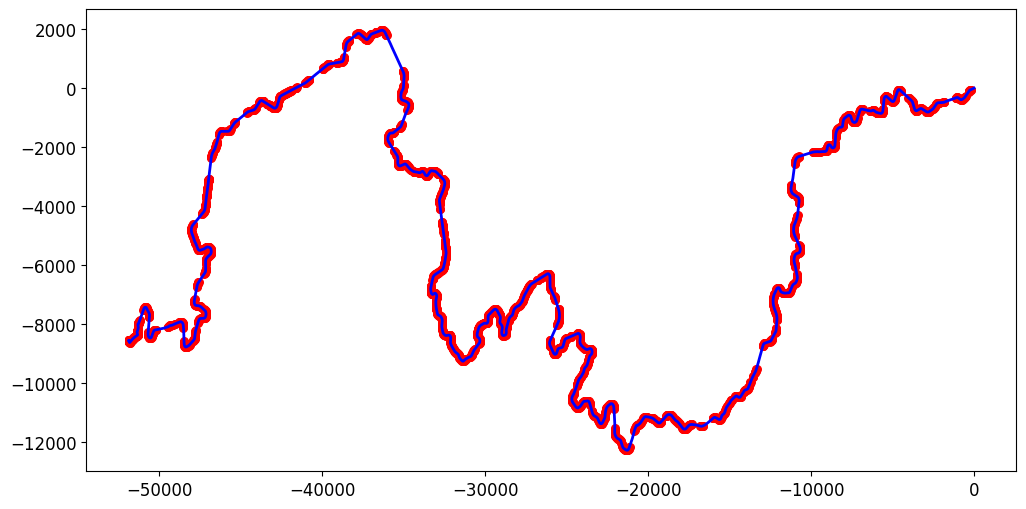

In [6]:
# Visualização dos trajetos (opcional)
for df in dfs:
    plot_trajeto_com_curvatura(df, sigma=cd['sigma'], limiar=cd['limiar'], limite_raio=cd['limite_raio'])


## 4. Detecção de Condução Perigosa

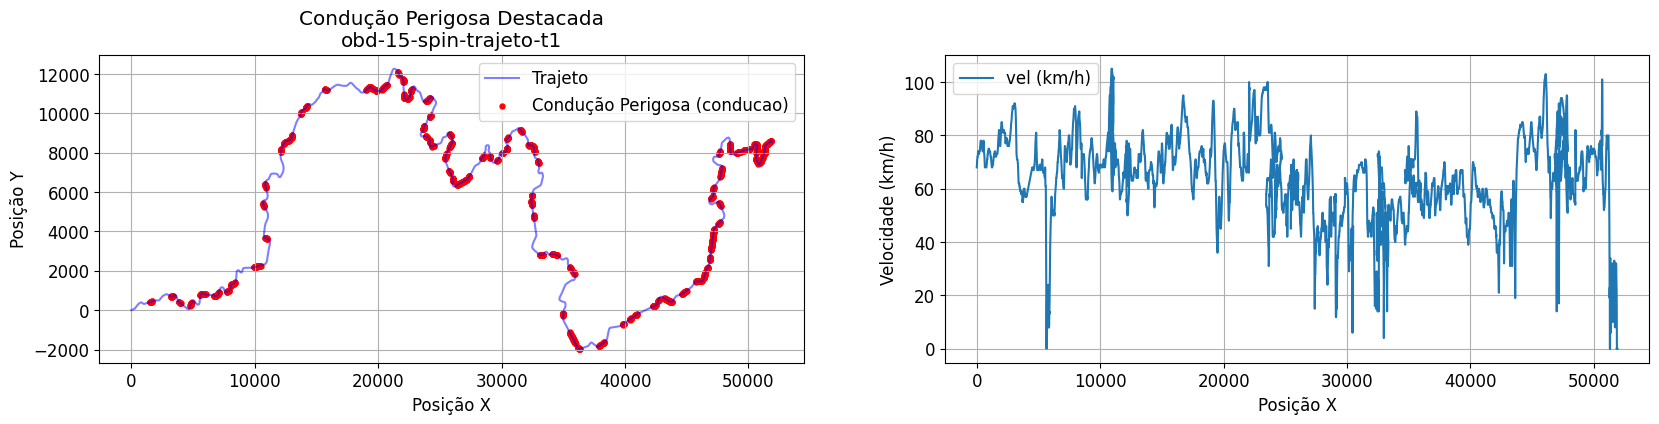

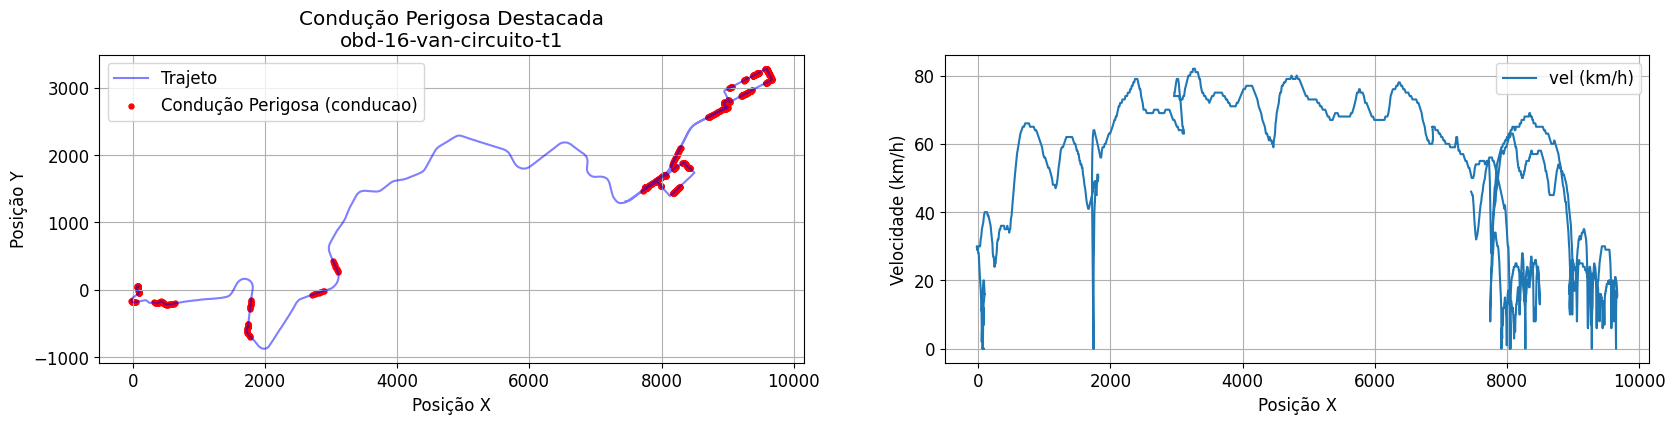

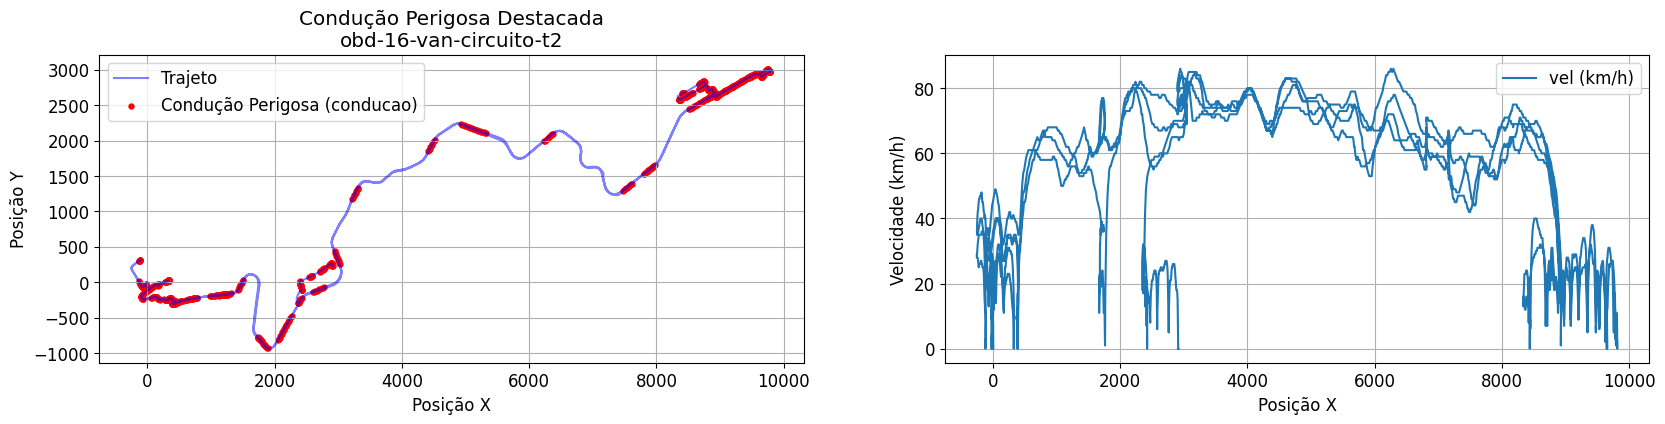

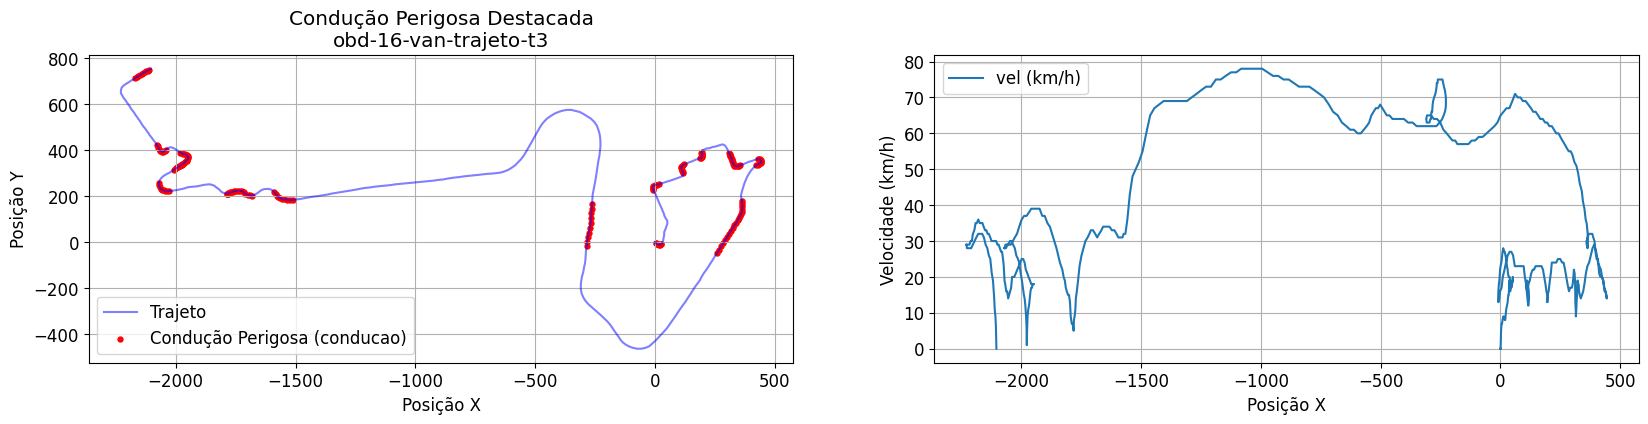

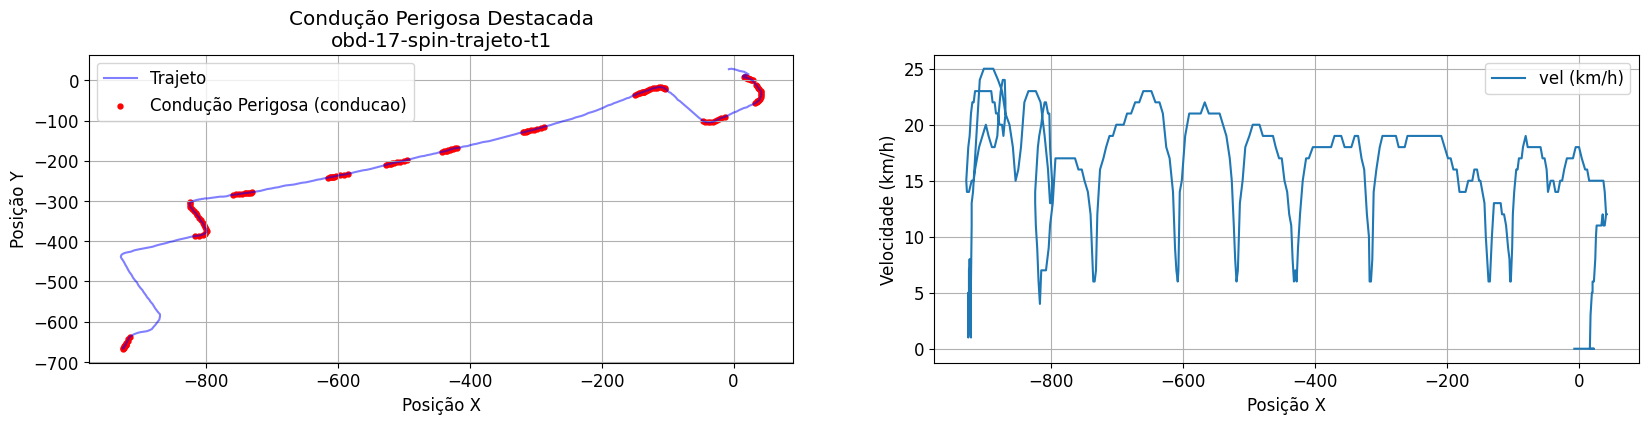

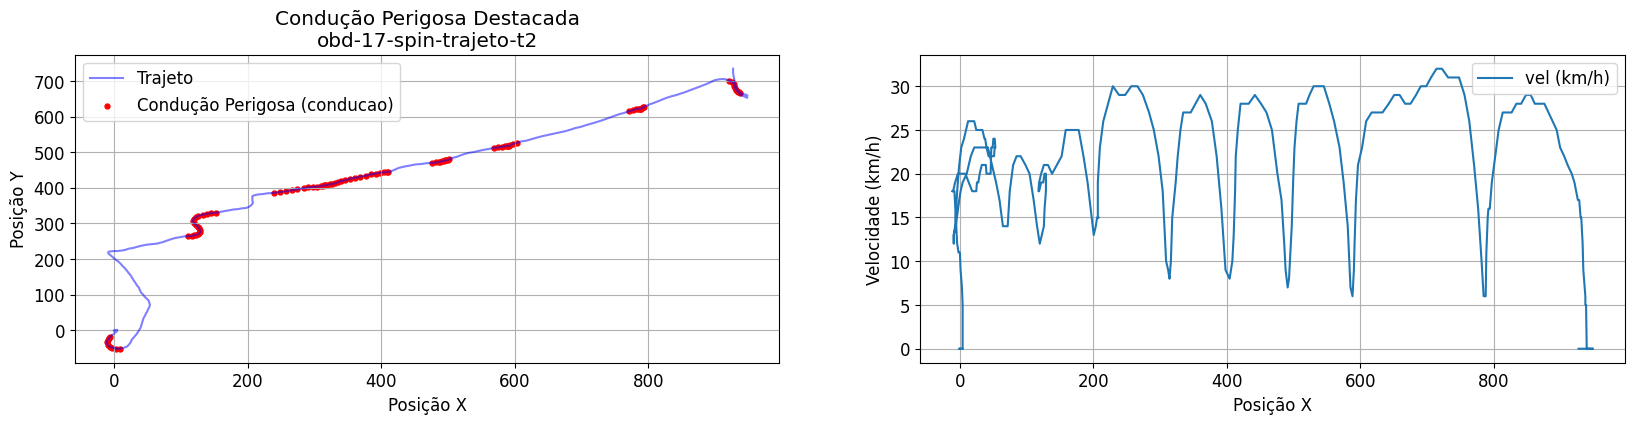

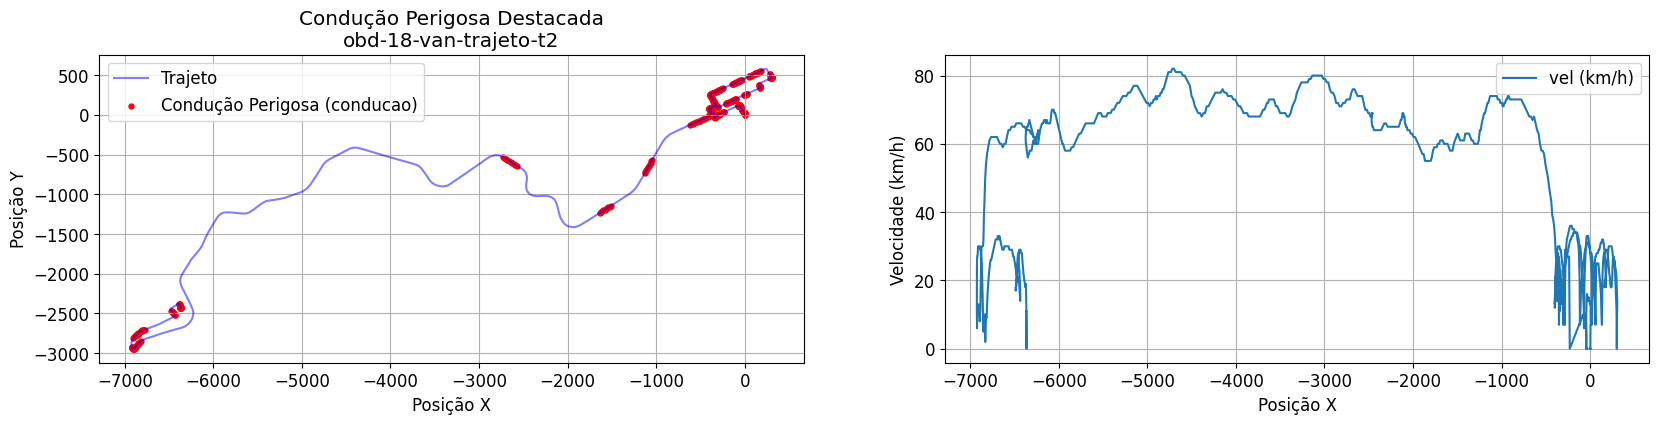

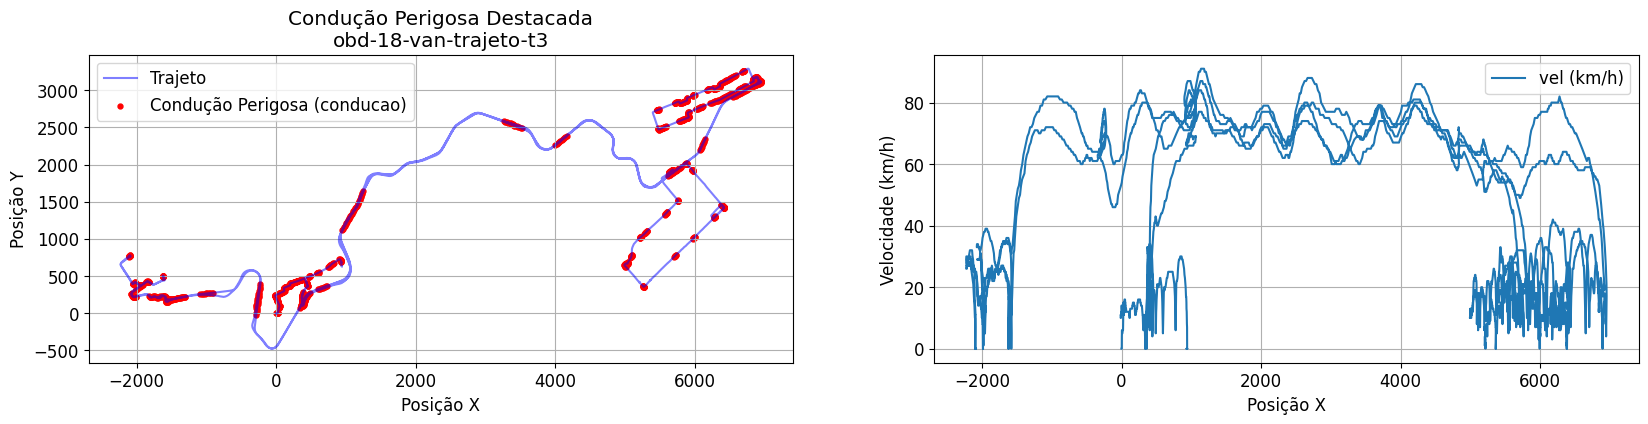

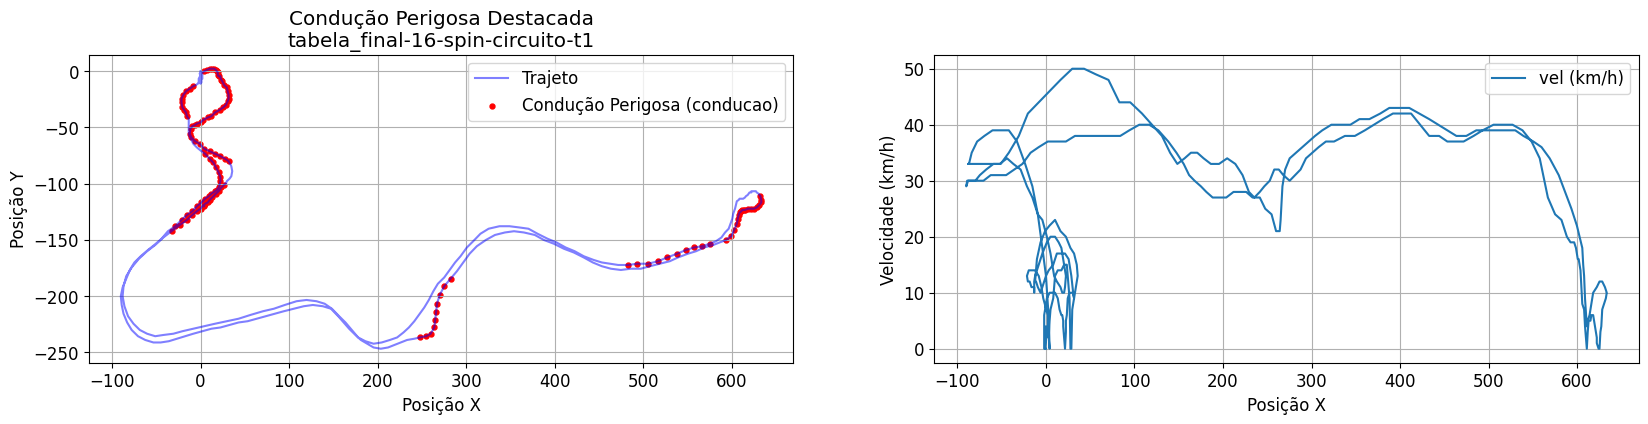

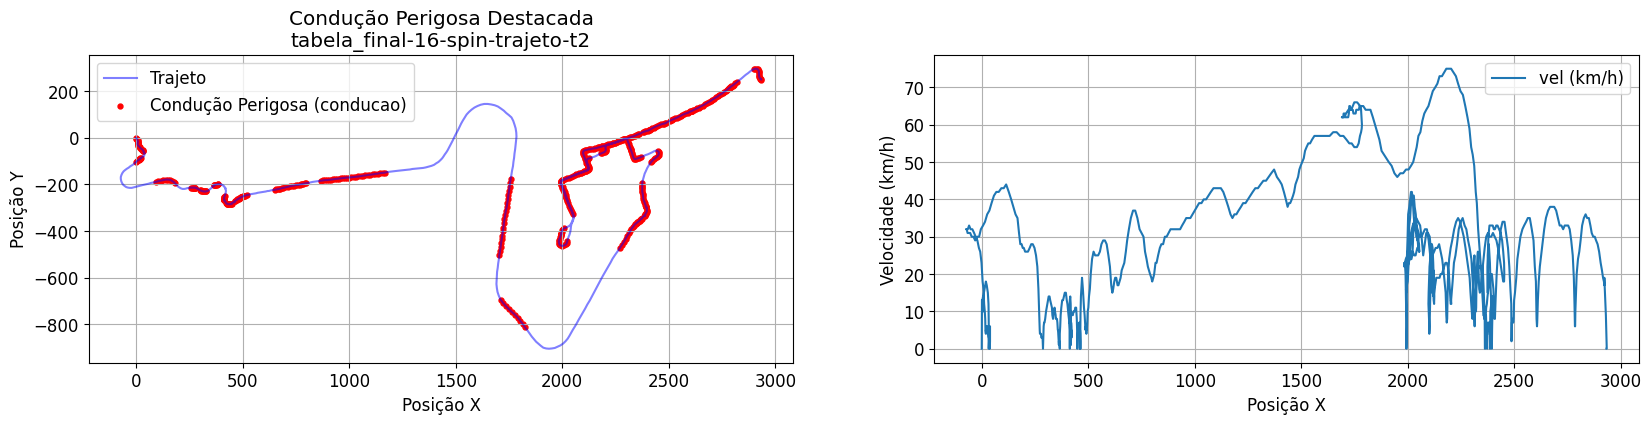

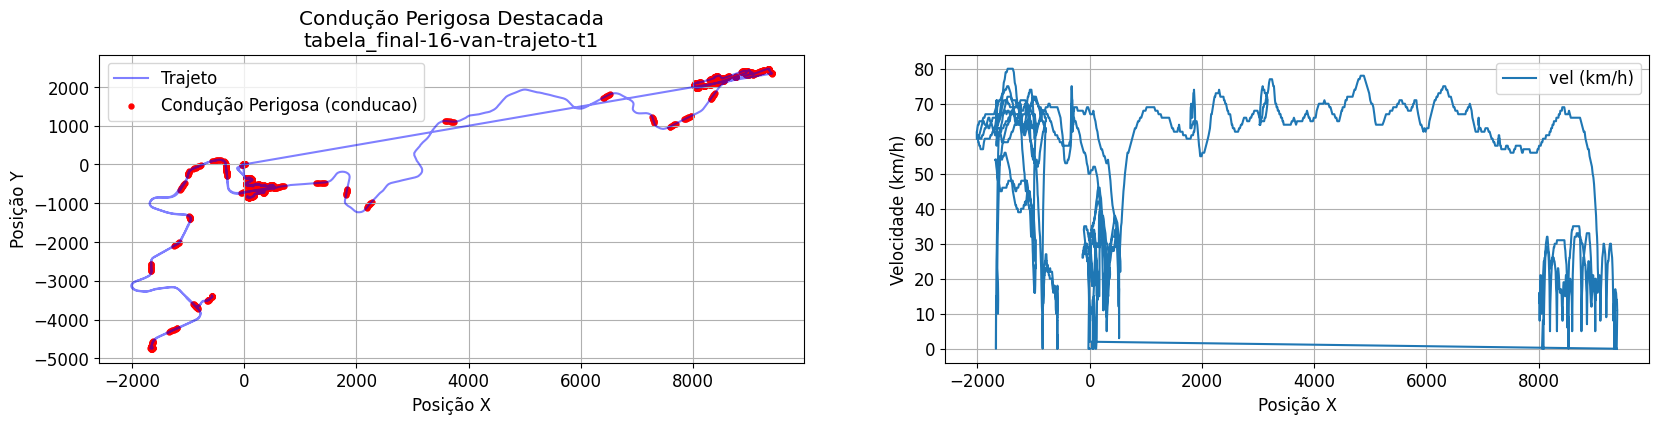

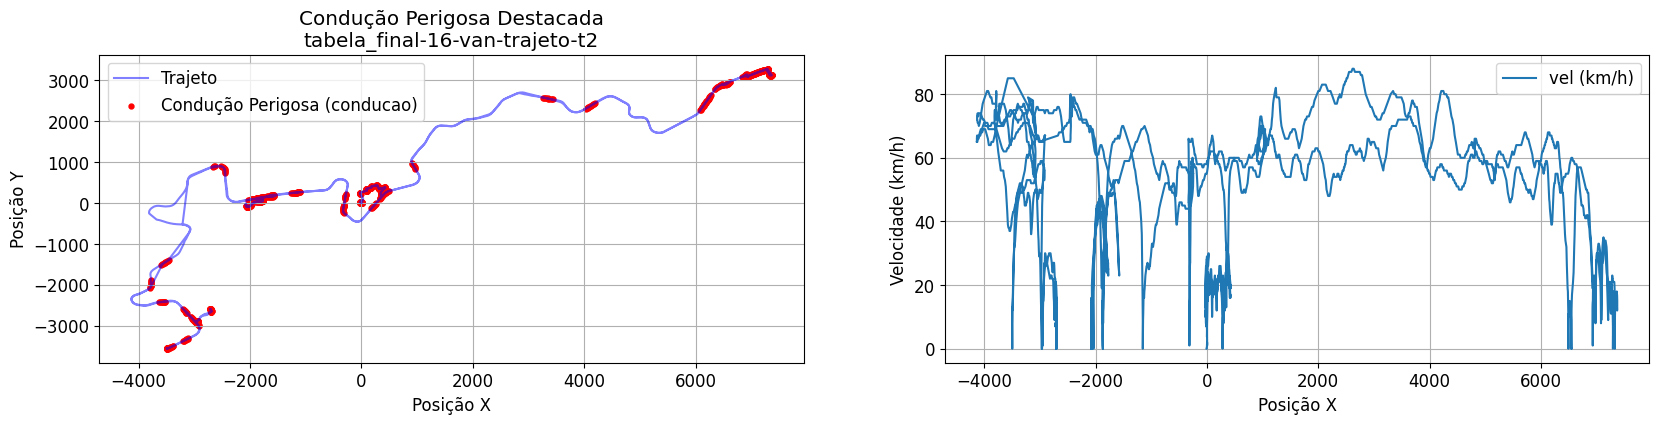

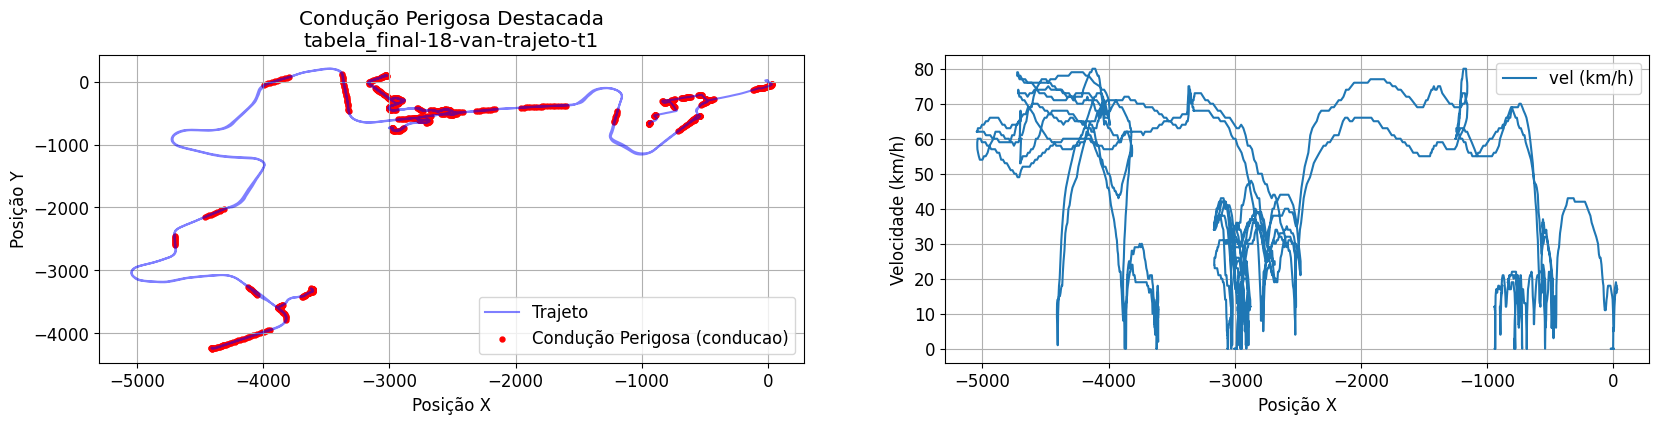

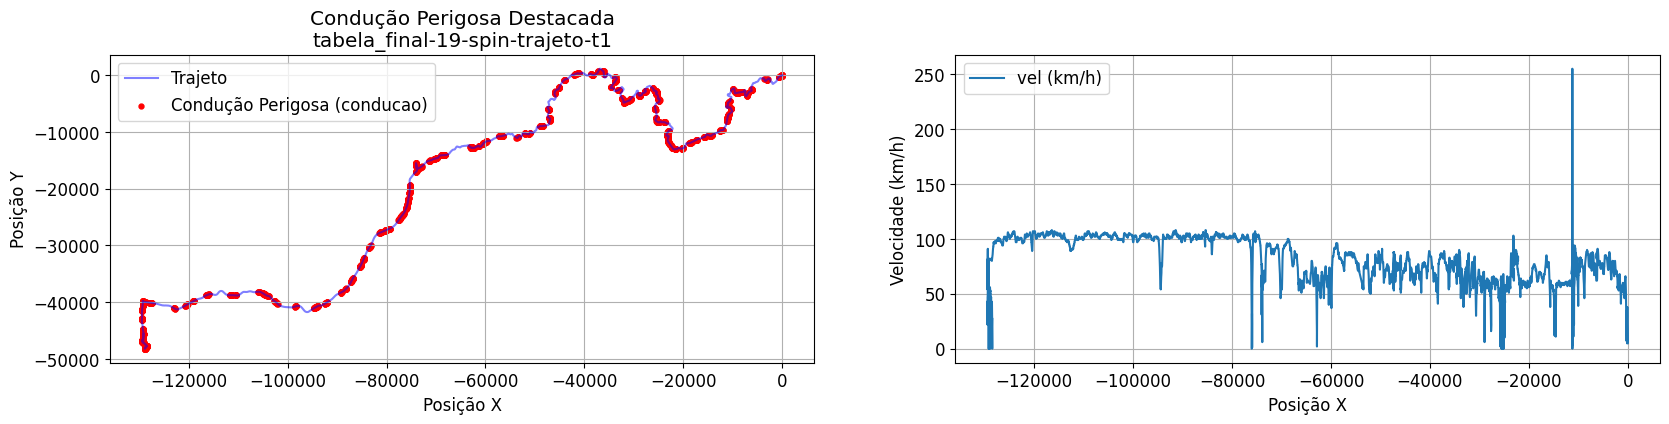

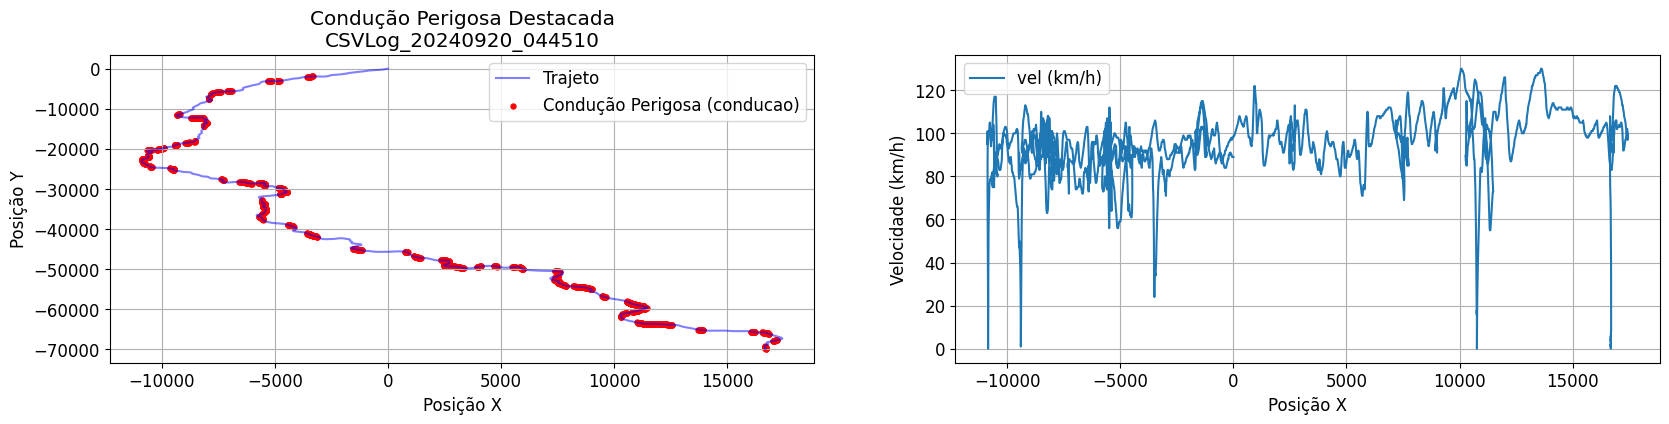

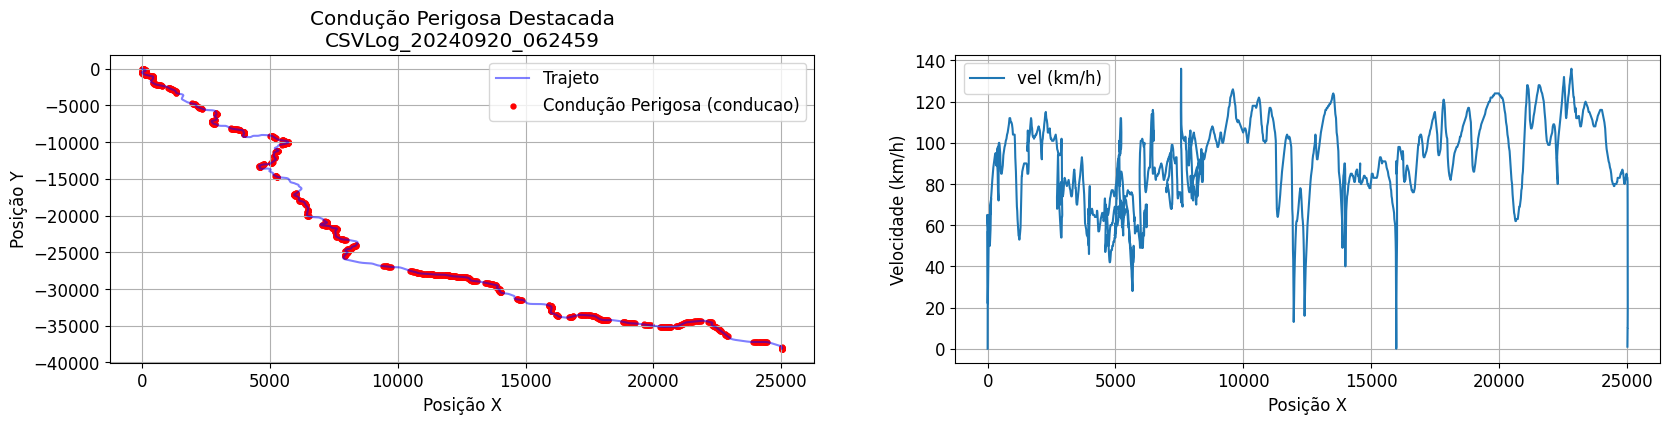

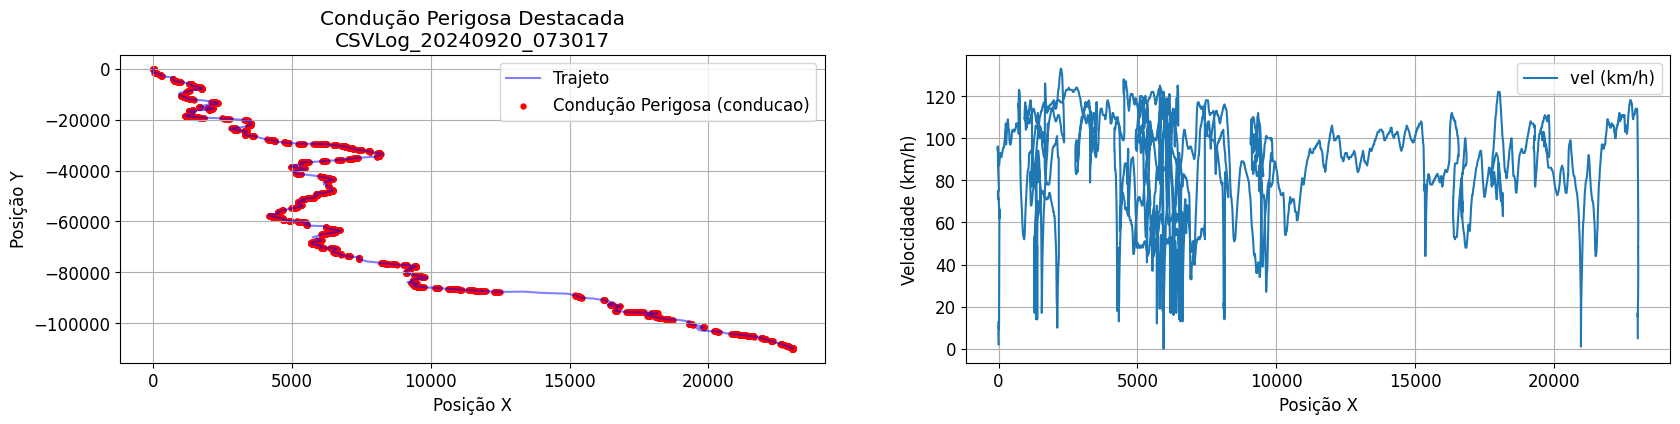

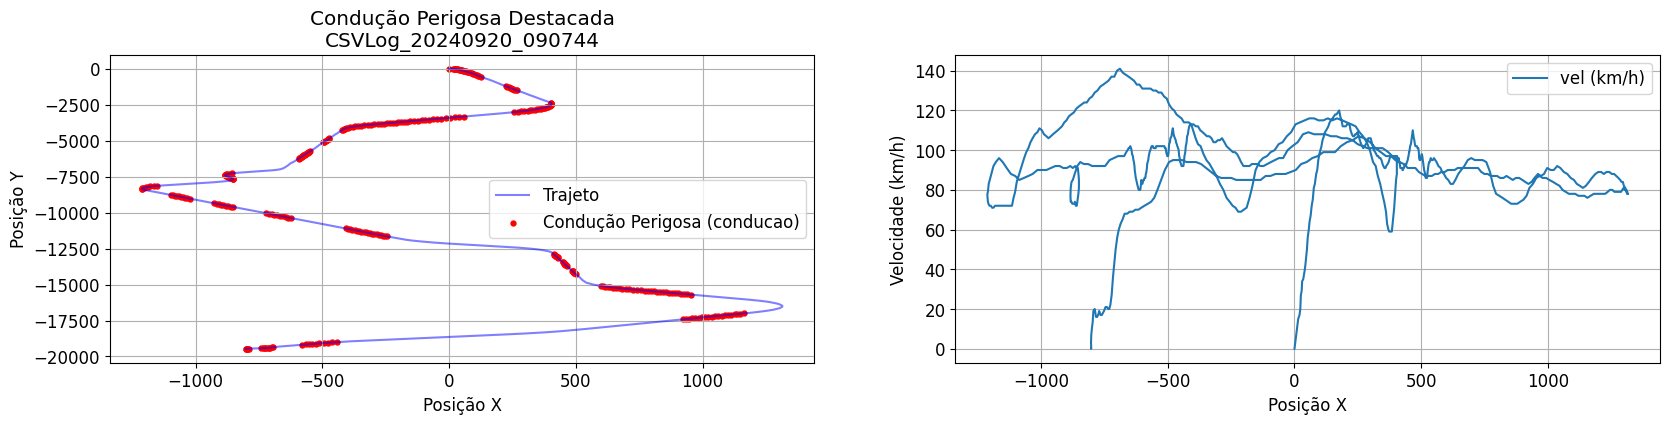

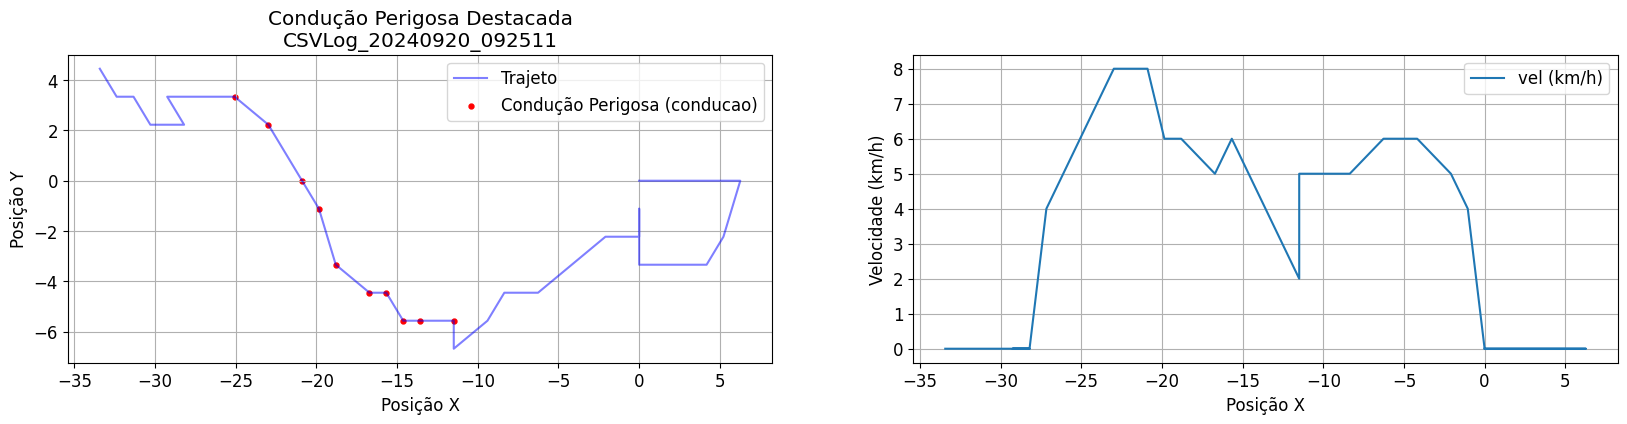

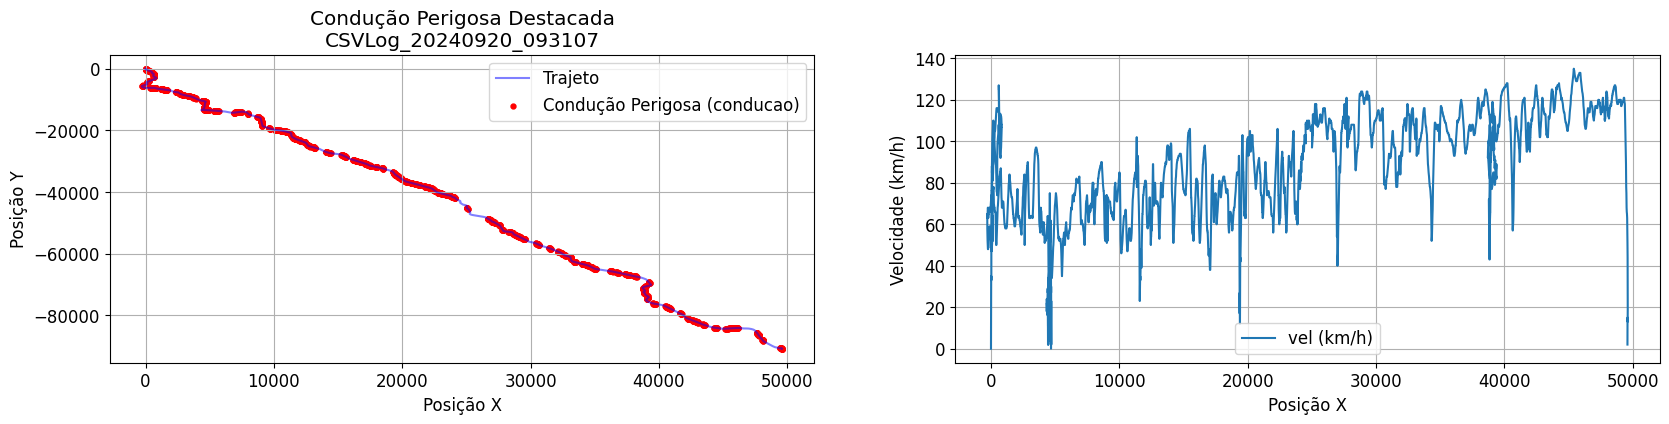

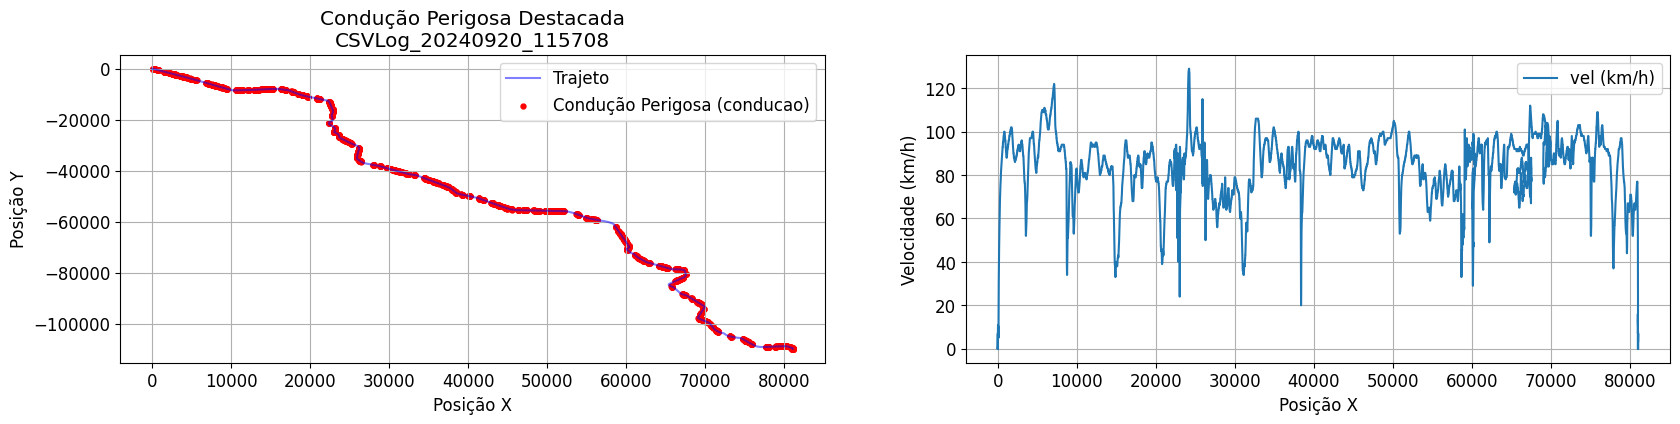

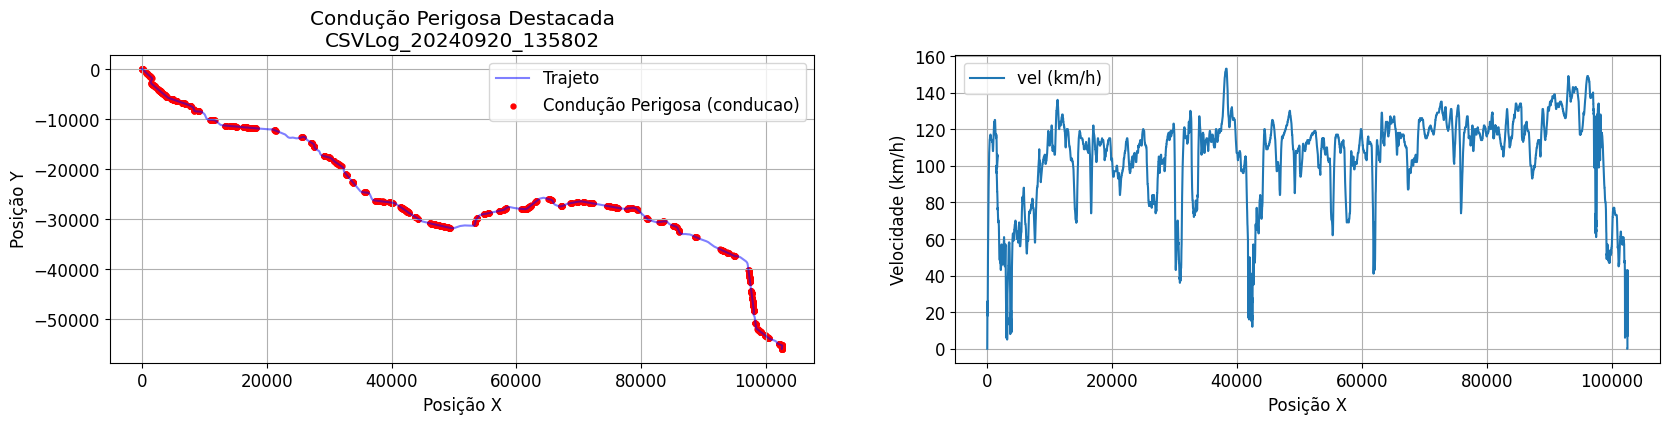

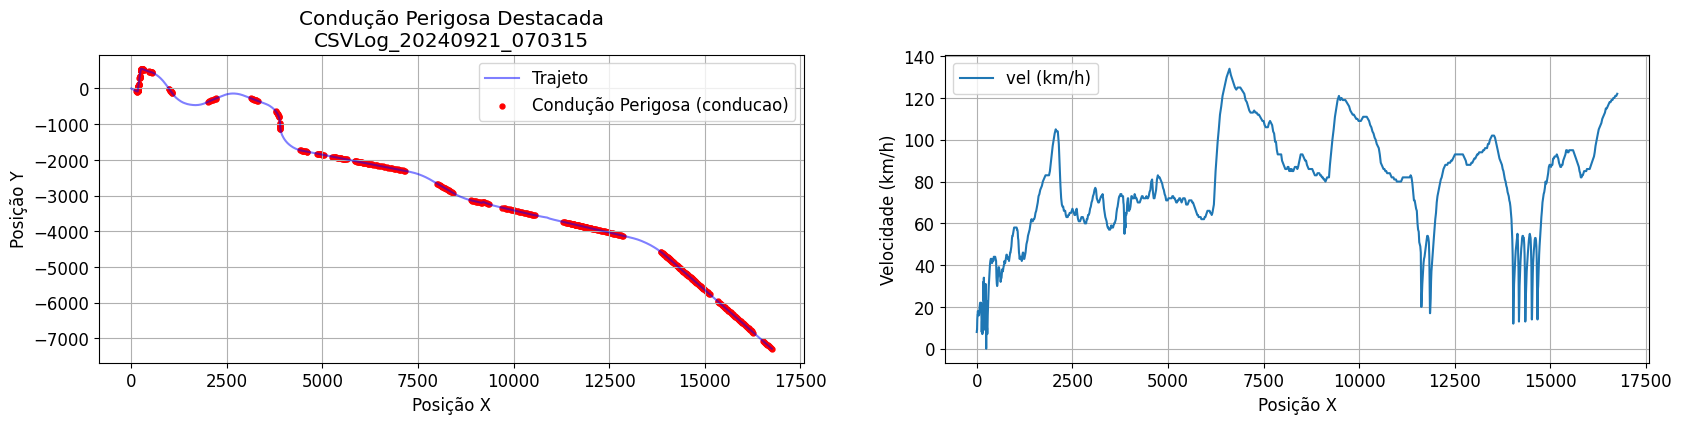

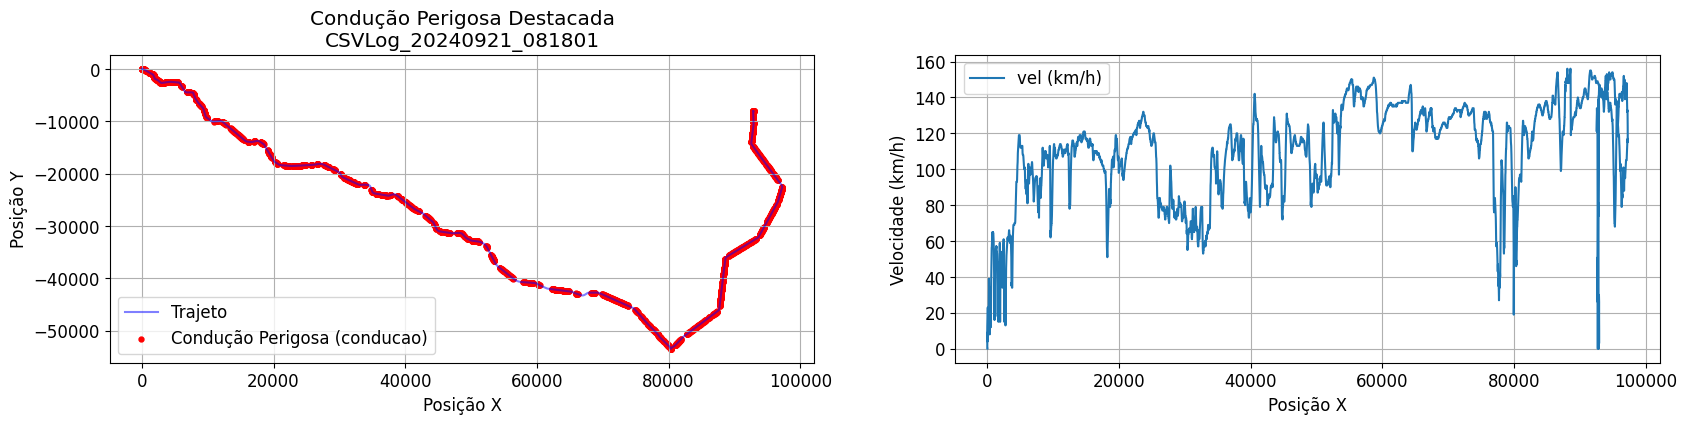

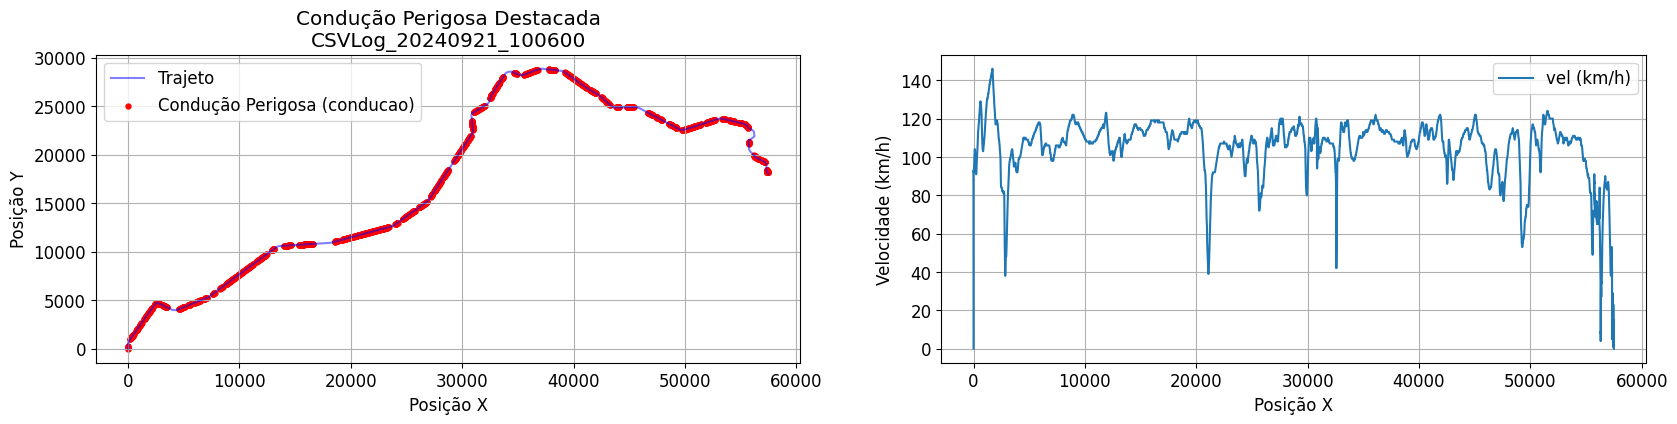

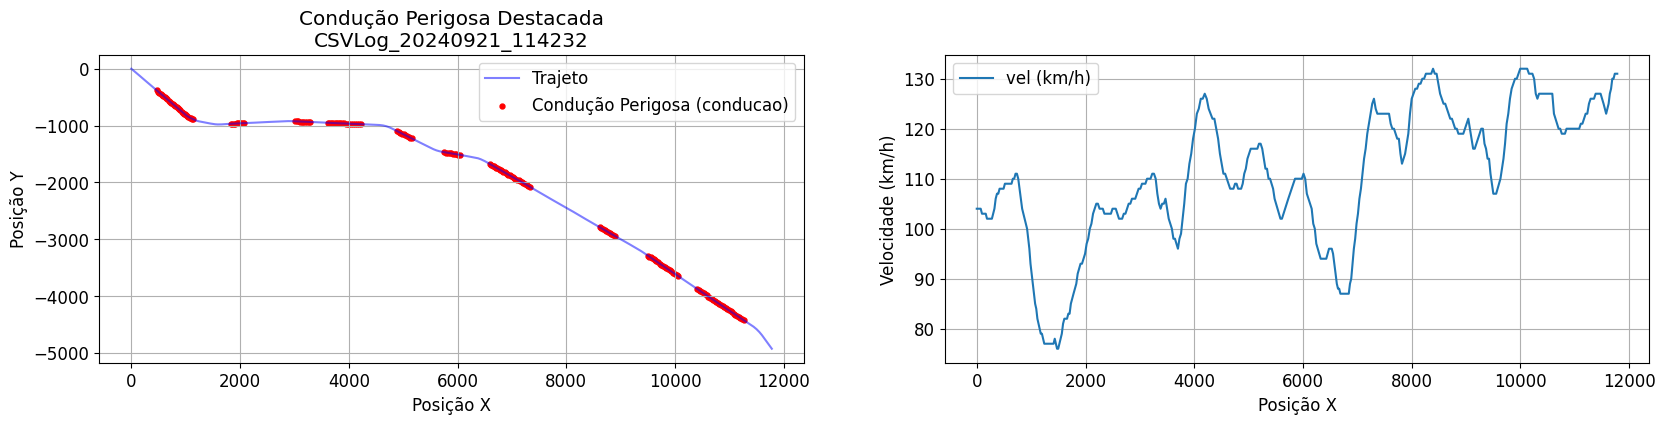

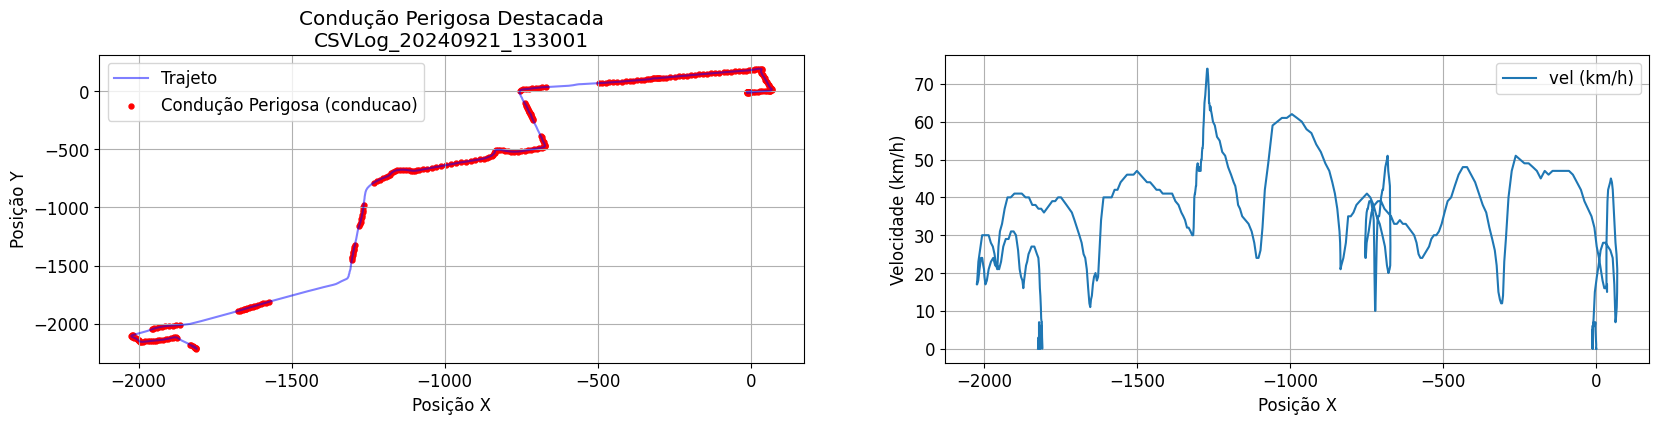

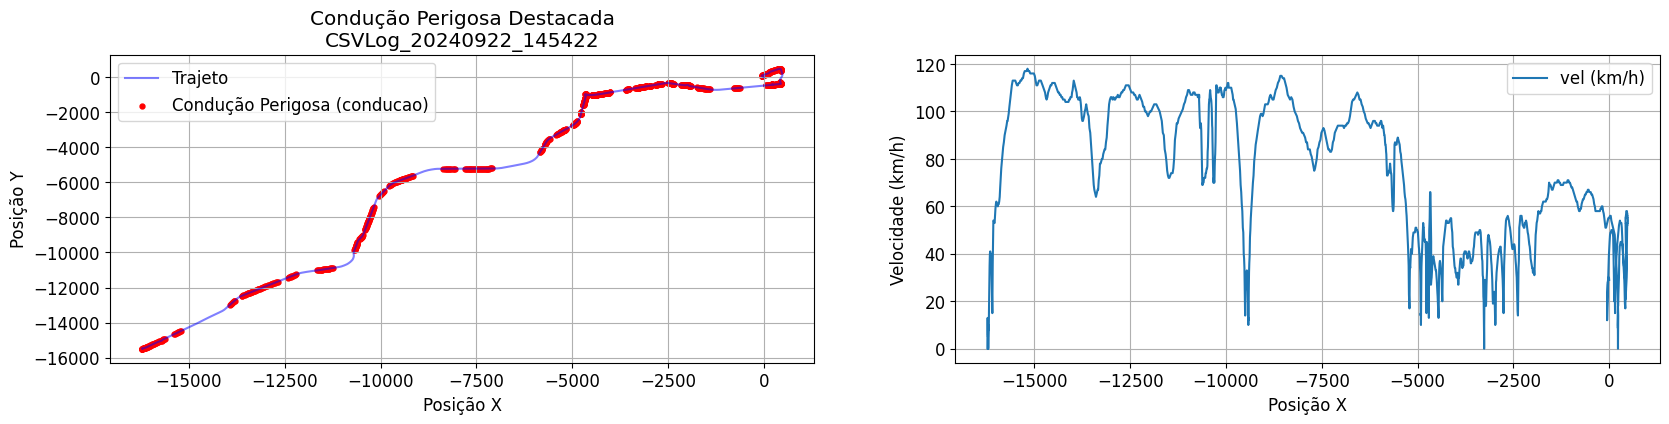

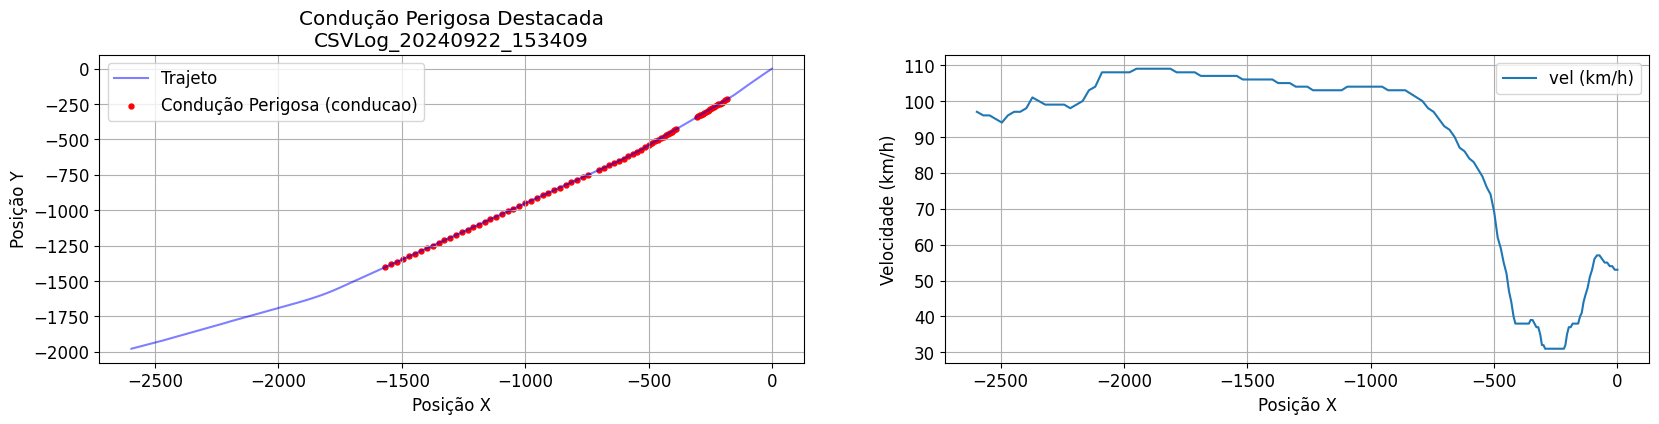

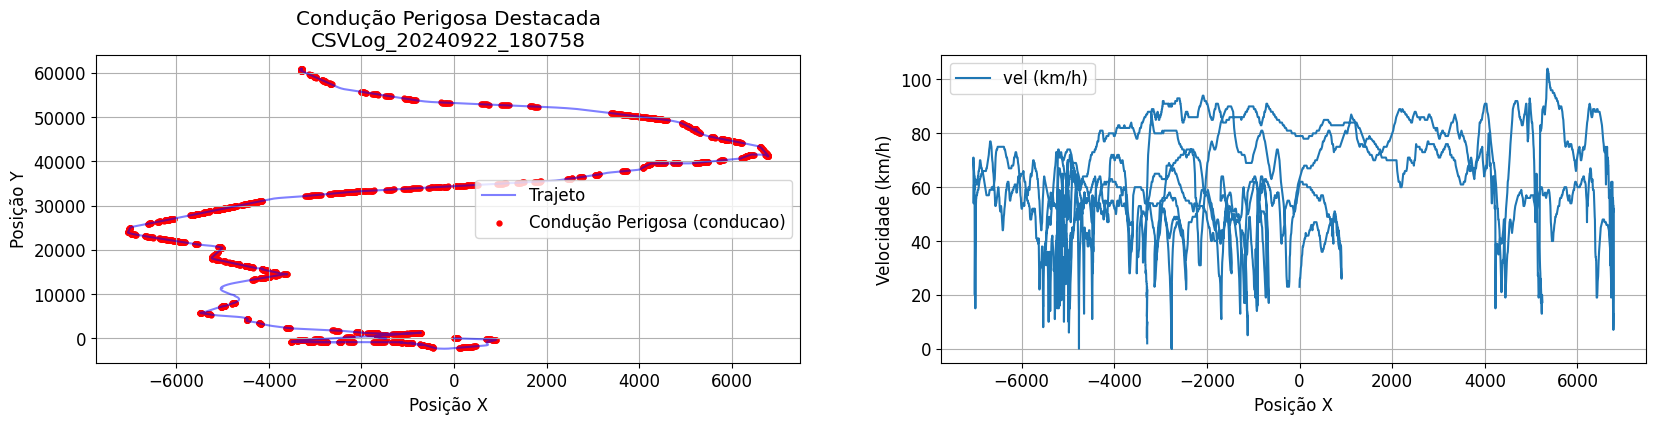

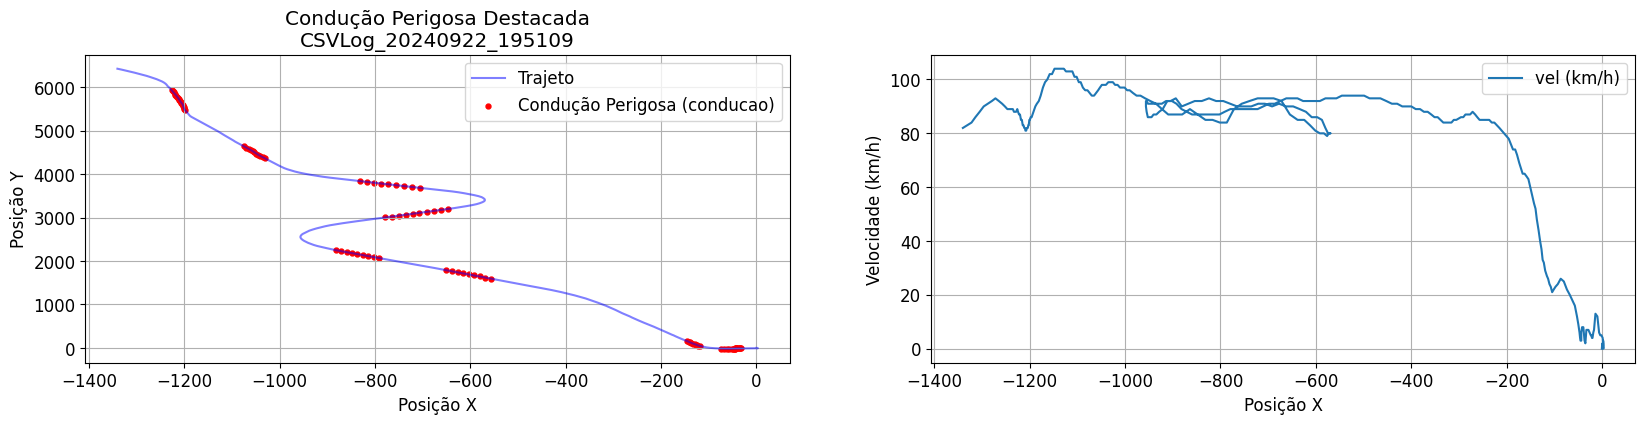

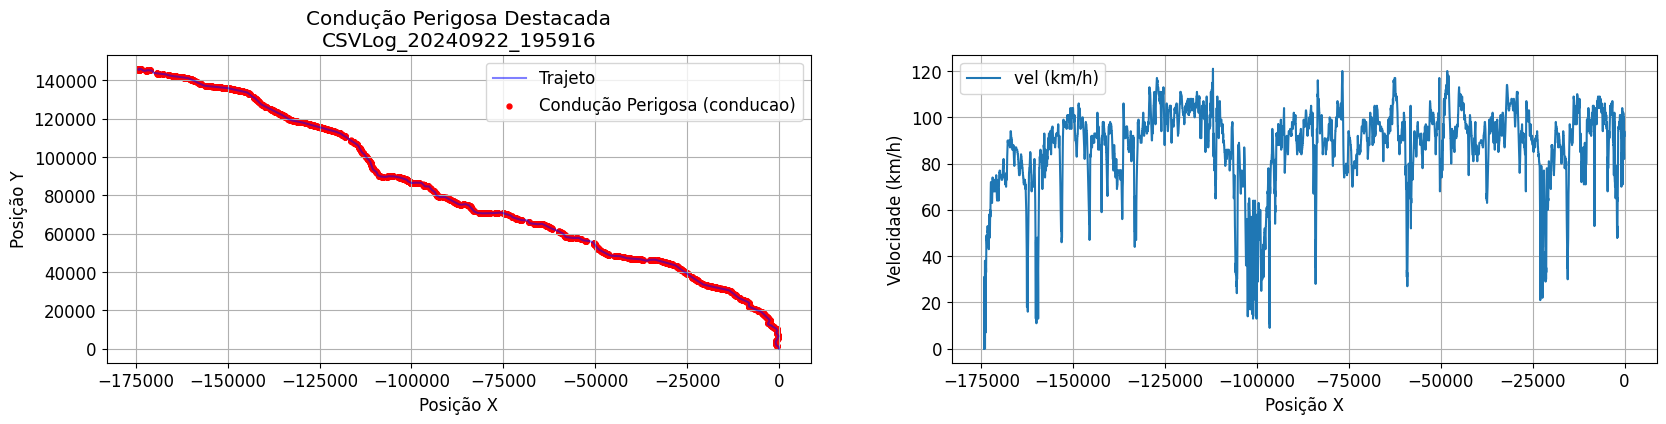

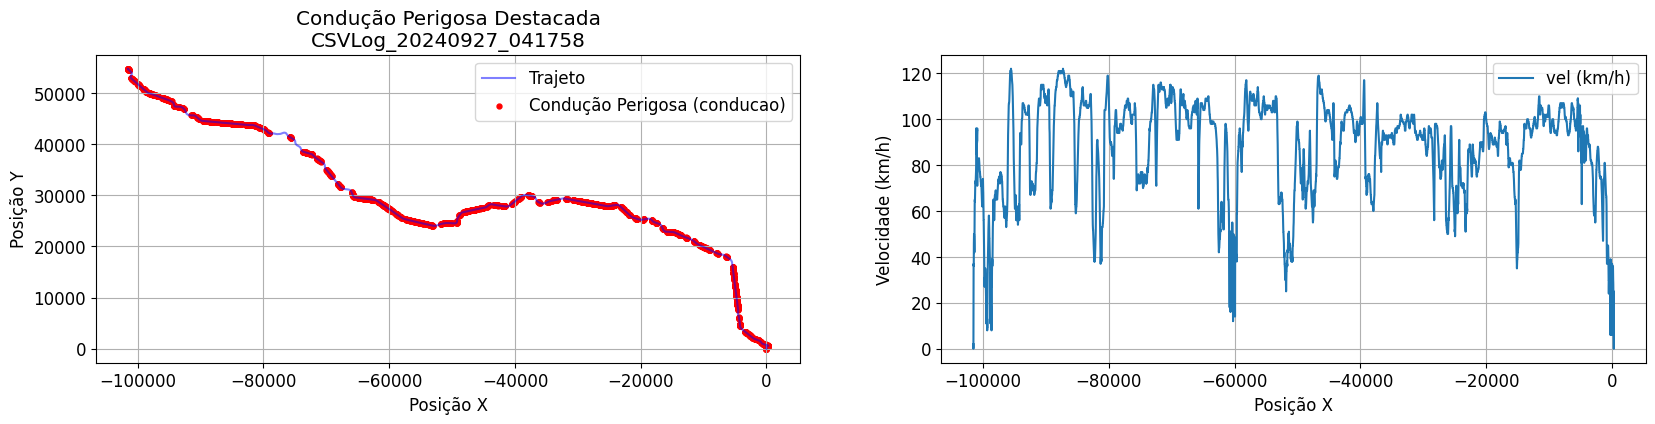

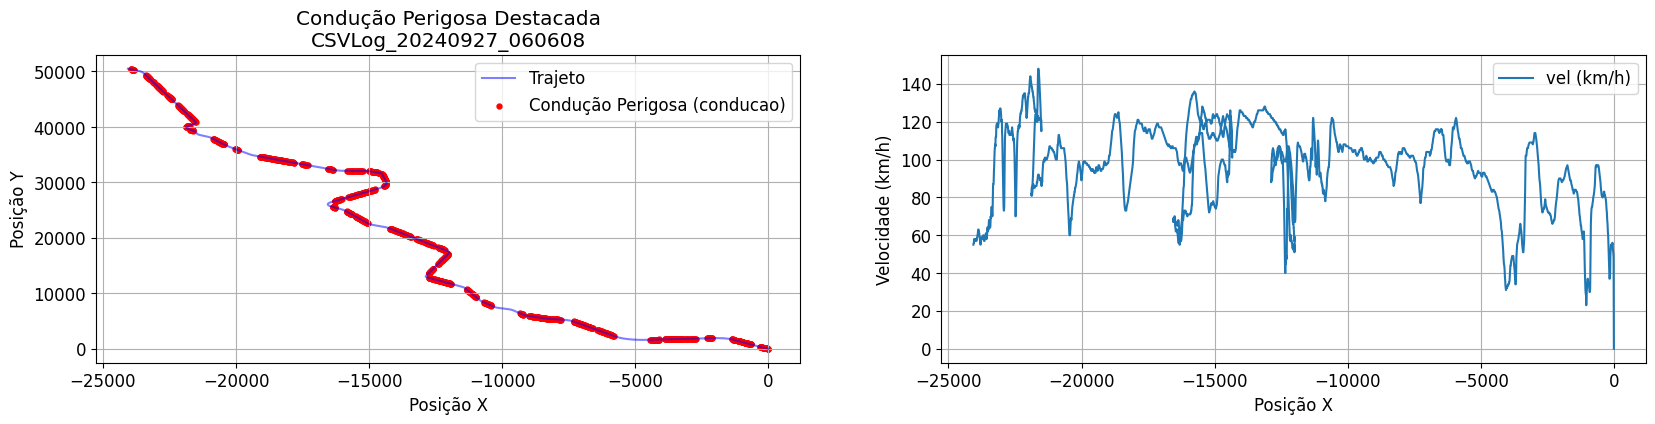

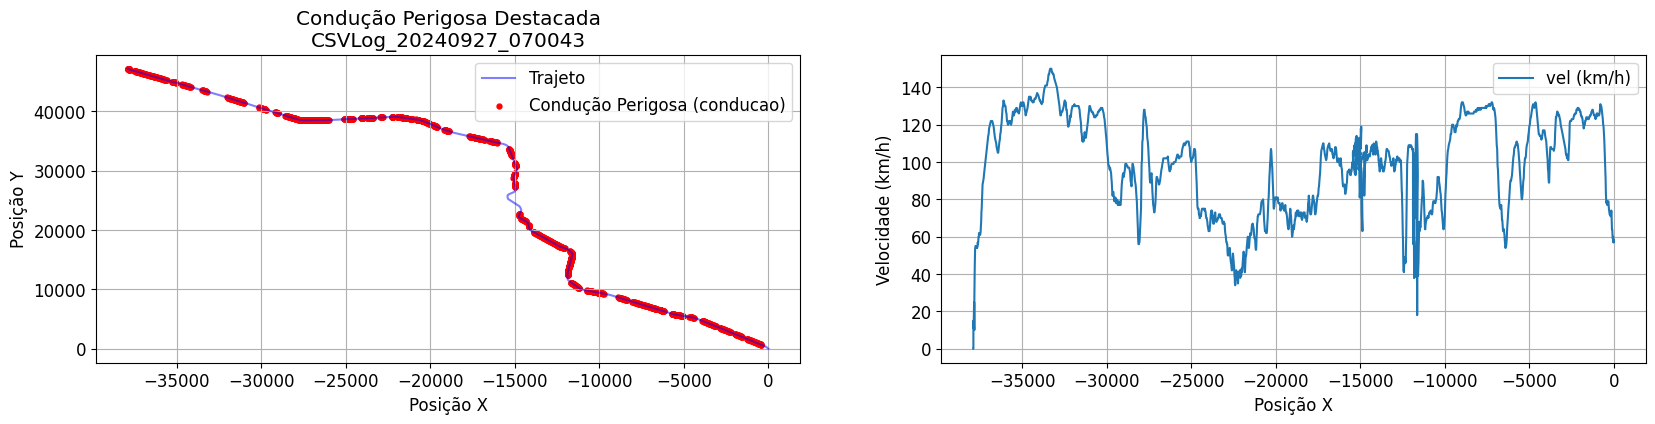

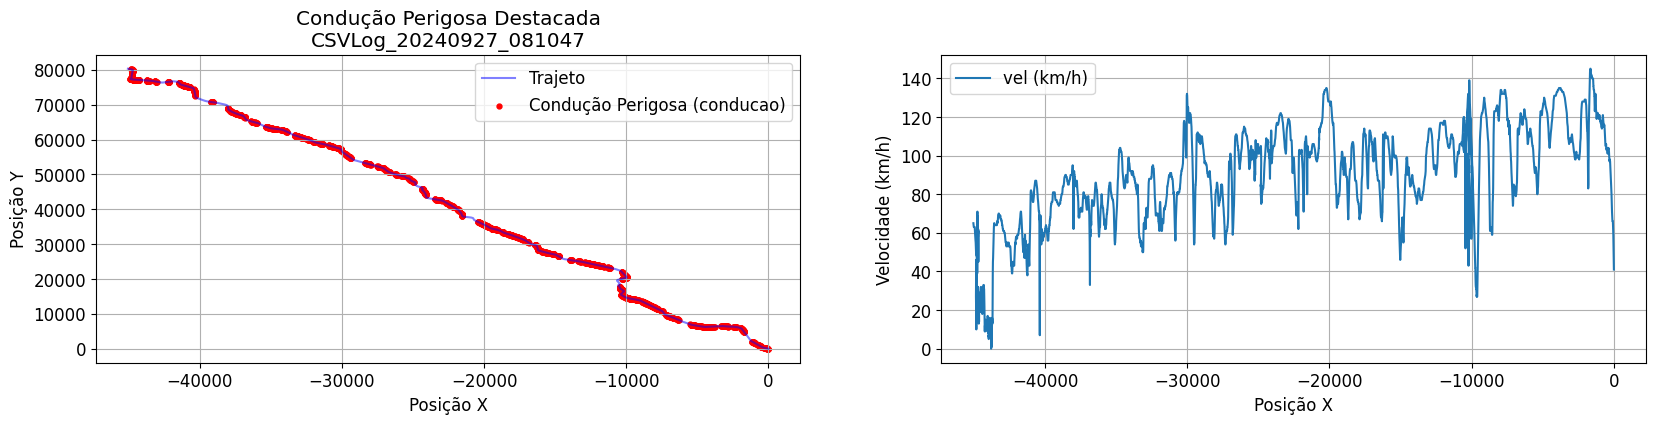

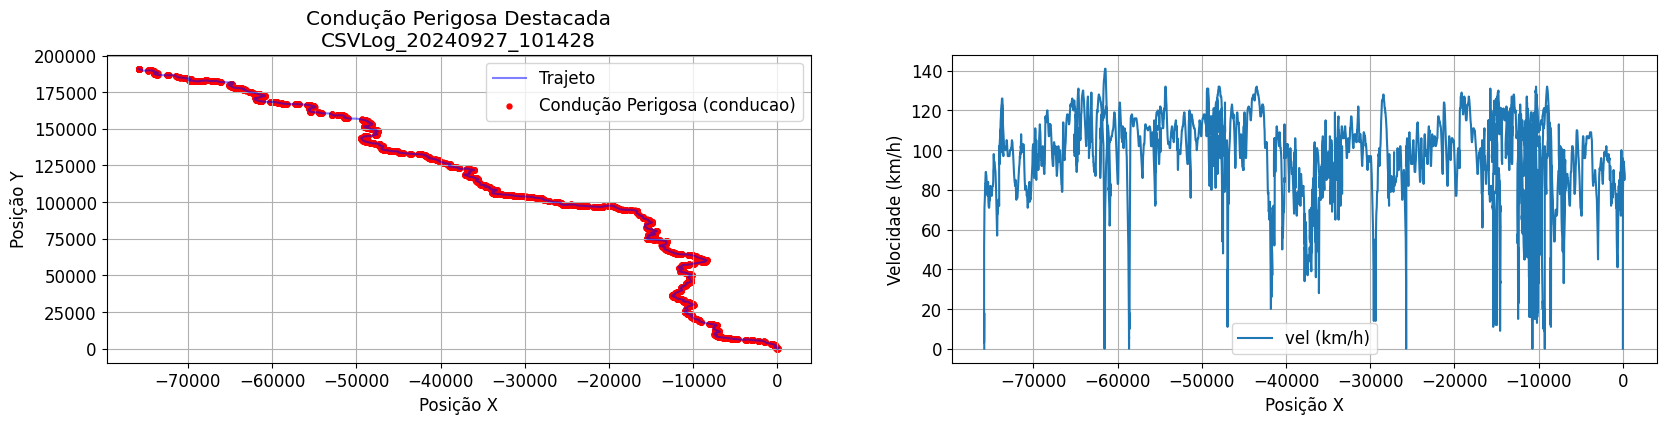

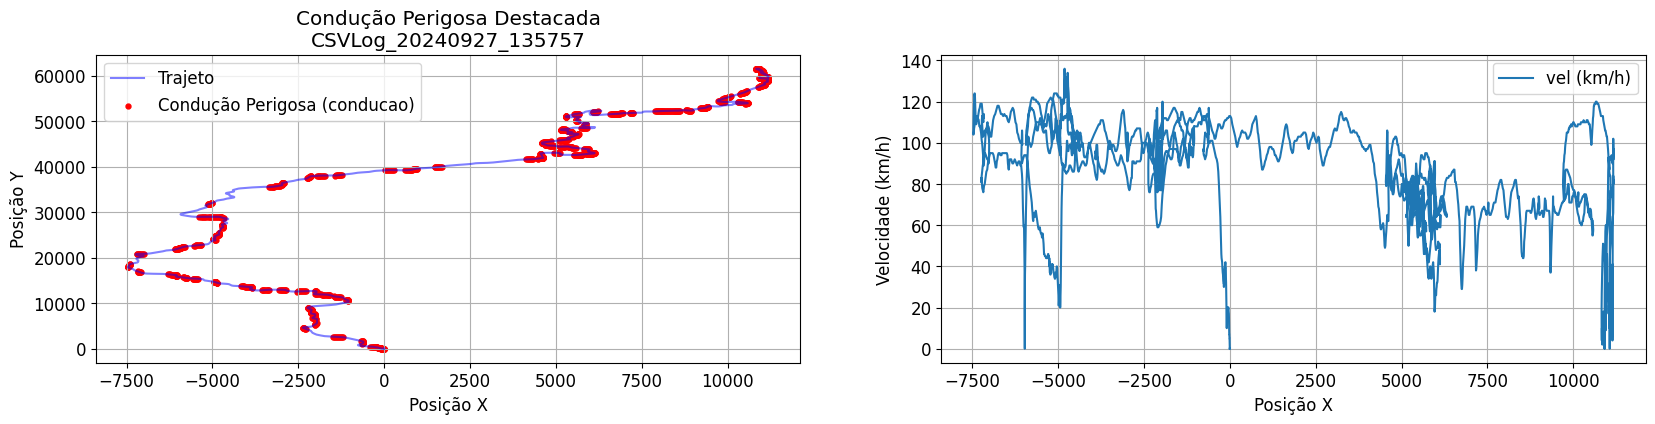

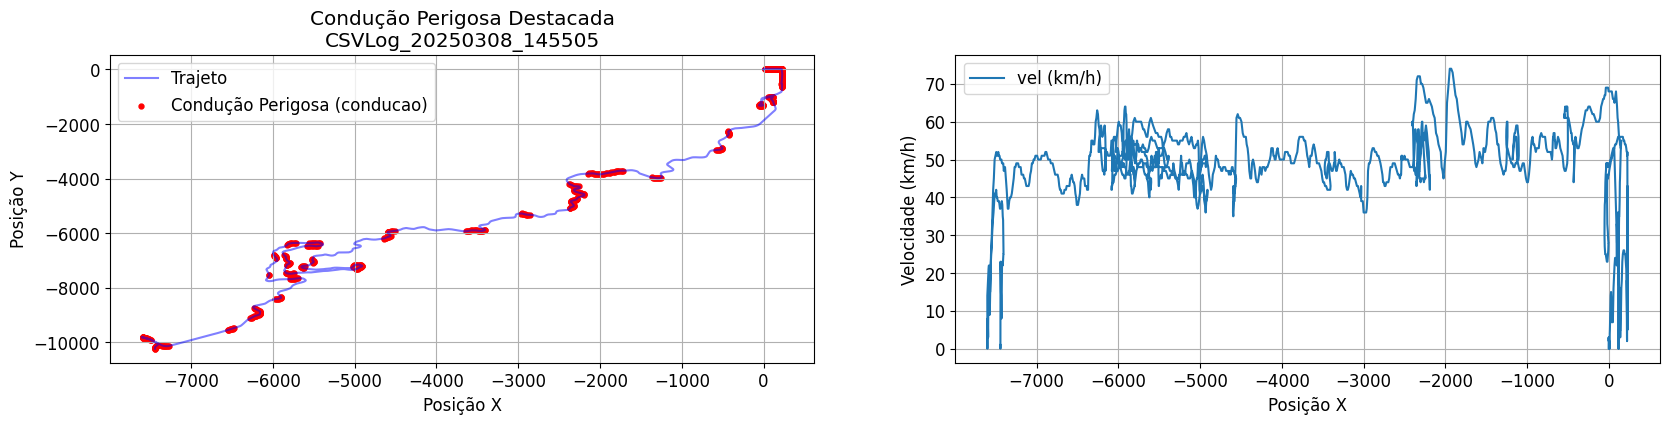

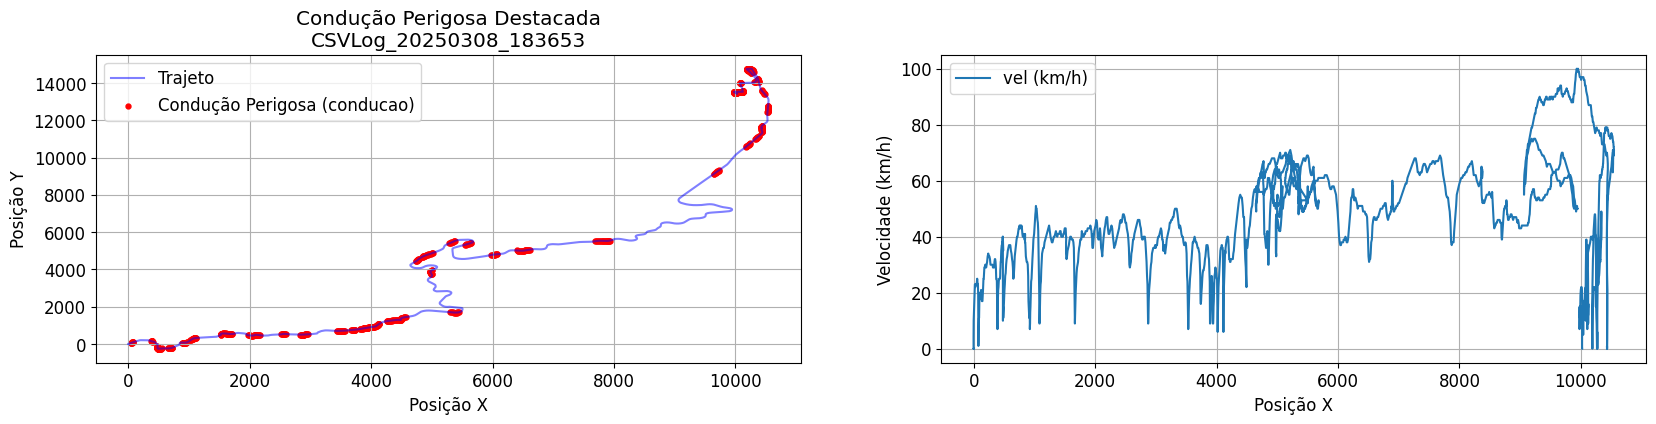

Trajetos após exclusão: 40


In [5]:
da = cfg['driving_analysis']

df_analysis = analisar_todos_trajetos(
    dfs_curves,
    janela_tempo=da['janela_tempo'],
    var_velocidade_max=da['var_velocidade_max'],
    velocidade_max_direcao=da['velocidade_max_direcao'],
    angulo_max_direcao=da['angulo_max_direcao'],
)

for traj in df_analysis['id_route'].unique():
    plotar_trajeto_conducao(df_analysis.query(f'id_route == "{traj}"'))

excluded = cfg['data']['excluded_routes']
df_analysis = df_analysis[~df_analysis['id_route'].isin(excluded)].reset_index(drop=True)
print(f'Trajetos após exclusão: {df_analysis["id_route"].nunique()}')


## 5. Extração de Features

In [6]:
df_analysis[['aceleracao_anormal', 'direcao_perigosa', 'zigue_zague']] = (
    df_analysis[['aceleracao_anormal', 'direcao_perigosa', 'zigue_zague']].astype(int)
)

df_trechos = identificar_trechos_curvos(df_analysis)
df_ml = extrair_features(df_trechos, janela_tempo=cfg['features']['janela_tempo'])

print(df_ml[['manobra', 'manobra_accel_perigo', 'manobra_dir_perigosa', 'manobra_zigue_zague']]
      .apply(pd.Series.value_counts).T)

stats = calcular_estatisticas_por_trajeto(df_trechos)
stats.to_latex('estatisticas_por_trajeto.tex', index=False, float_format='%.2f')
stats


Janela vazia para CSVLog_20240920_044510 e trecho 877
Janela vazia para CSVLog_20240920_062459 e trecho 0
Janela vazia para CSVLog_20240920_073017 e trecho 1081
Janela vazia para CSVLog_20240920_090744 e trecho 1231
Janela vazia para CSVLog_20240920_092511 e trecho 1254
Janela vazia para CSVLog_20240920_093107 e trecho 1257
Janela vazia para CSVLog_20240920_115708 e trecho 1380
Janela vazia para CSVLog_20240920_135802 e trecho 1586
Janela vazia para CSVLog_20240921_070315 e trecho 1711
Janela vazia para CSVLog_20240921_081801 e trecho 1726
Janela vazia para CSVLog_20240921_100600 e trecho 1829
Janela vazia para CSVLog_20240921_114232 e trecho 1908
Janela vazia para CSVLog_20240921_133001 e trecho 1919
Janela vazia para CSVLog_20240922_145422 e trecho 1929
Janela vazia para CSVLog_20240922_153409 e trecho 1955
Janela vazia para CSVLog_20240922_180758 e trecho 1959
Janela vazia para CSVLog_20240922_195109 e trecho 2081
Janela vazia para CSVLog_20240922_195916 e trecho 2087
Janela vazia p

,id_trajeto,numb_curve,v,theta,a_x,a_y,a_z
0,CSVLog_20240920_044510,125,90.36,62.54,0.02,0.02,0.04
1,CSVLog_20240920_062459,81,81.61,71.52,-0.03,-0.00,0.02
2,CSVLog_20240920_073017,151,81.87,53.63,0.02,0.00,-0.01
3,CSVLog_20240920_090744,24,91.03,22.87,-0.03,0.02,0.01
4,CSVLog_20240920_092511,3,2.74,62.98,0.05,-0.07,0.35
5,CSVLog_20240920_093107,124,80.60,21.35,-0.02,0.02,-0.02
6,CSVLog_20240920_115708,207,80.15,13.52,0.00,0.03,0.03
7,CSVLog_20240920_135802,126,92.57,13.67,-0.03,0.00,0.02
8,CSVLog_20240921_070315,15,64.42,6.45,0.01,0.01,0.02
9,CSVLog_20240921_081801,104,100.71,5.92,-0.04,0.00,0.02


## 6. Modelos de Machine Learning Clássicos

Regressão Logística — Acurácia: 0.7017


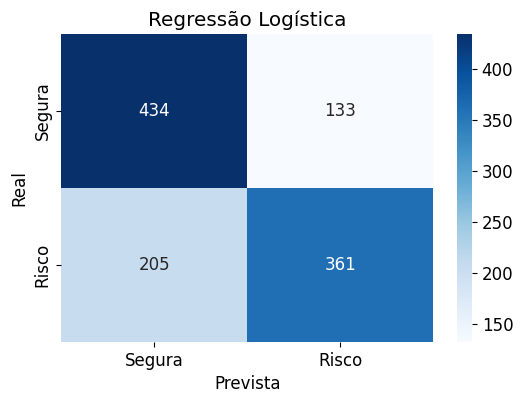

SVM — Acurácia: 0.6867


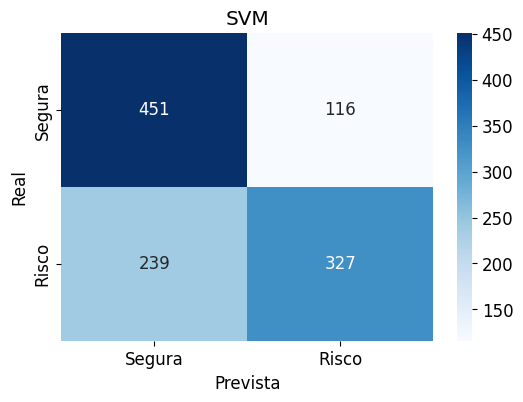

Árvore de Decisão — Acurácia: 0.6637


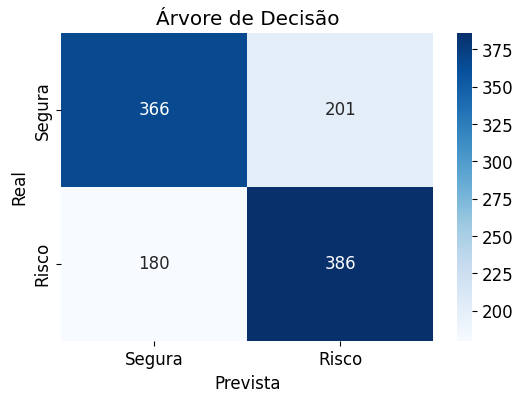

Floresta Aleatória — Acurácia: 0.7714


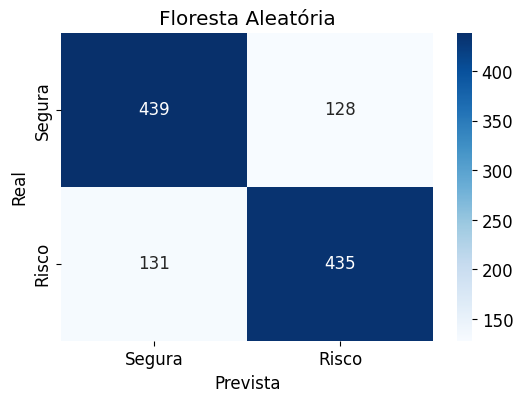

Rede Neural (MLP) — Acurácia: 0.7308


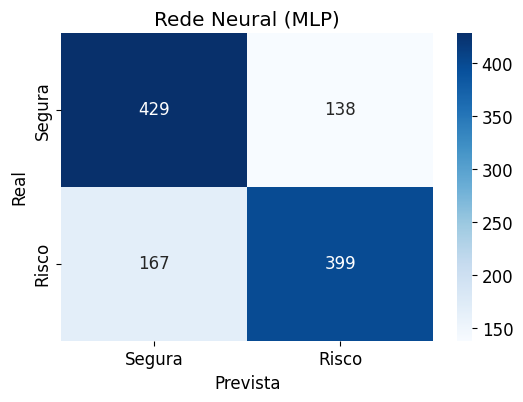

Classificador,Bloco,Floresta Aleatória,Rede Neural (MLP),Regressão Logística,SVM,Árvore de Decisão
0,Bloco 1,0.661376,0.638889,0.656085,0.638889,0.620370
1,Bloco 2,0.614570,0.578808,0.623841,0.642384,0.596026
2,Bloco 3,0.622517,0.654305,0.705960,0.752318,0.590728
3,Bloco 4,0.765563,0.727152,0.696689,0.688742,0.682119
4,Bloco 5,0.572185,0.634437,0.547020,0.605298,0.609272


In [9]:
ml = cfg['ml']

df_resultados = aplicar_modelos_ml(
    df_ml,
    plot_cm=True,
    random_state=ml['random_state'],
    test_size=ml['test_size'],
    cv_folds=ml['cv_folds'],
)
df_resultados


## 7. Redes Neurais

Melhores parâmetros: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate': 'constant', 'solver': 'adam'}
Acurácia — Treino: 1.0000 | Teste: 0.7308
Aviso: possível overfitting detectado.


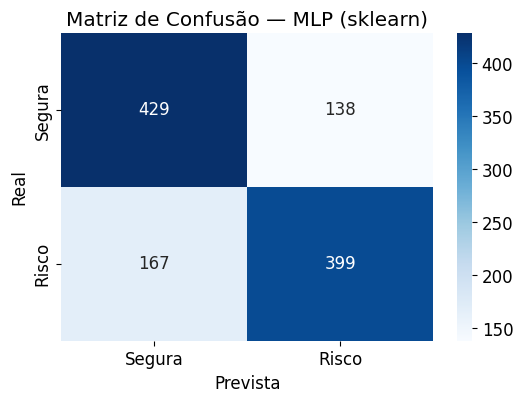

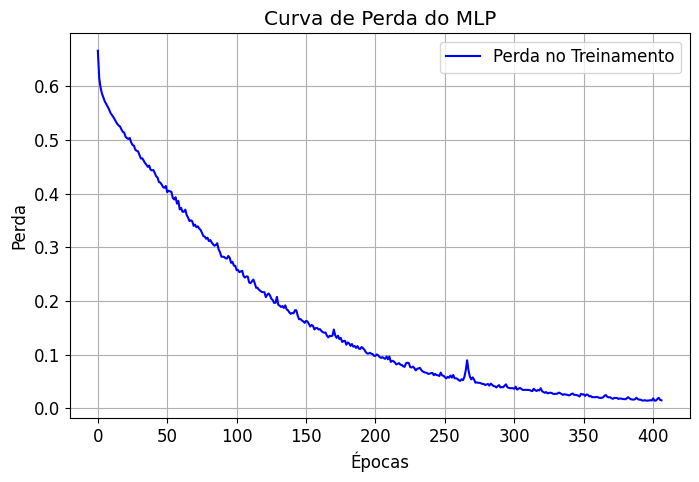

In [10]:
modelo_mlp_sk = treinar_mlp_sklearn(df_ml, random_state=ml['random_state'])


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,050 (39.26 KB)

 Trainable params: 10,050 (39.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5691 - loss: 0.6822 - val_accuracy: 0.6805 - val_loss: 0.6256
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6235 - loss: 0.6614 - val_accuracy: 0.7127 - val_loss: 0.6048
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6391 - loss: 0.6382 - val_accuracy: 0.7127 - val_loss: 0.5916
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6552 - loss: 0.6313 - val_accuracy: 0.7127 - val_loss: 0.5763
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6556 - loss: 0.6224 - val_accuracy: 0.7278 - val_loss: 0.5728
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6717 - loss: 0.6115 - val_accuracy: 0.7353 - val_loss: 0.5681
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6727 - loss: 0.6156 - val_accuracy: 0.7486 - val_loss: 0.5703
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6693 - loss: 0.6056 - val_accuracy: 0.7372 - val_loss:

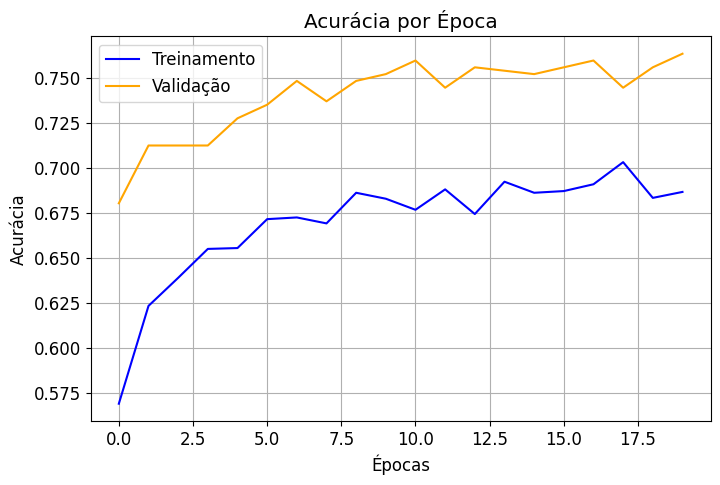

In [13]:
X_train, X_test, y_train, y_test = preparar_dados_keras(df_ml, random_state=ml['random_state'])
nn_cfg = cfg['neural_networks']['mlp_keras']

modelo_mlp = construir_mlp_keras(X_train.shape[1])
modelo_mlp.summary()

history = modelo_mlp.fit(
    X_train, y_train,
    epochs=nn_cfg['epochs'],
    batch_size=nn_cfg['batch_size'],
    validation_split=nn_cfg['validation_split'],
    verbose=1,
)
plotar_curva_treinamento(history)


Epoch 1/10


c:\Users\abece\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4904 - loss: 0.7041 - val_accuracy: 0.5508 - val_loss: 0.6820
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5322 - loss: 0.6861 - val_accuracy: 0.5982 - val_loss: 0.6661
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5679 - loss: 0.6748 - val_accuracy: 0.6208 - val_loss: 0.6545
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5950 - loss: 0.6655 - val_accuracy: 0.6637 - val_loss: 0.6439
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6160 - loss: 0.6561 - val_accuracy: 0.6637 - val_loss: 0.6320
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6284 - loss: 0.6463 - val_accuracy: 0.6975 - val_loss: 0.6194
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6437 - loss: 0.6360 - val_accuracy: 0.7088 - val_loss: 0.6082
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6635 - loss: 0.6262 - val_accuracy: 0.7088 - val_loss: 0.5972
Ep

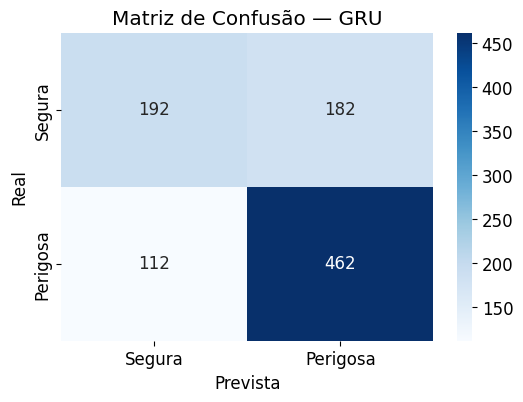

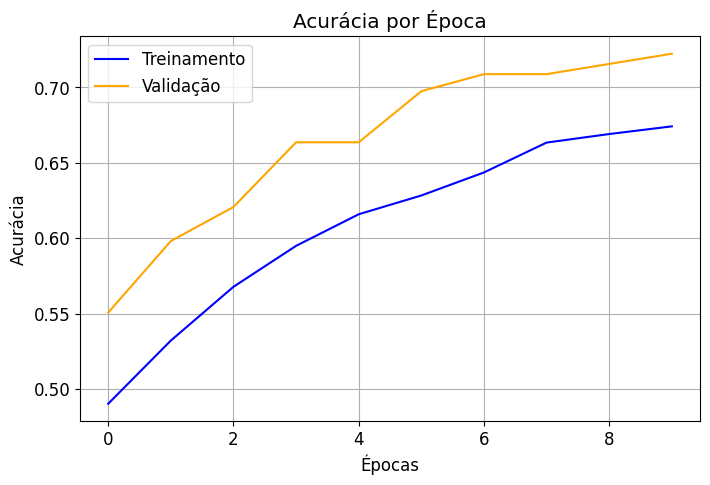

In [14]:
from sklearn.metrics import confusion_matrix

gru_cfg = cfg['neural_networks']['gru']
X_train_g, X_test_g, y_train_g, y_test_g, n_feat = preparar_dados_gru(
    df_ml, janela_tempo=gru_cfg['janela_tempo'], random_state=ml['random_state']
)
modelo_gru = construir_gru(gru_cfg['janela_tempo'], n_feat)

history_gru = modelo_gru.fit(
    X_train_g, y_train_g,
    epochs=gru_cfg['epochs'],
    batch_size=gru_cfg['batch_size'],
    validation_split=gru_cfg['validation_split'],
    verbose=1,
)

y_pred_gru = np.argmax(modelo_gru.predict(X_test_g), axis=1)
y_true_gru = np.argmax(y_test_g, axis=1)

cm = confusion_matrix(y_true_gru, y_pred_gru)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Segura', 'Perigosa'], yticklabels=['Segura', 'Perigosa'])
plt.title('Matriz de Confusão — GRU')
plt.ylabel('Real'); plt.xlabel('Prevista')
plt.show()

plotar_curva_treinamento(history_gru)


c:\Users\abece\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,266 (137.76 KB)

 Trainable params: 35,266 (137.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5939 - loss: 0.6771 - val_accuracy: 0.6659 - val_loss: 0.6409
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6459 - loss: 0.6402 - val_accuracy: 0.7043 - val_loss: 0.5925
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6759 - loss: 0.6156 - val_accuracy: 0.7314 - val_loss: 0.5703
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6878 - loss: 0.6032 - val_accuracy: 0.7359 - val_loss: 0.5606
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6923 - loss: 0.5987 - val_accuracy: 0.7291 - val_loss: 0.5575
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6957 - loss: 0.5930 - val_accuracy: 0.7336 - val_loss: 0.5608
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7014 - loss: 0.5906 - val_accuracy: 0.7223 - val_loss: 0.5539
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6974 - loss: 0.5887 - val_accuracy: 0.7314 - val_loss:

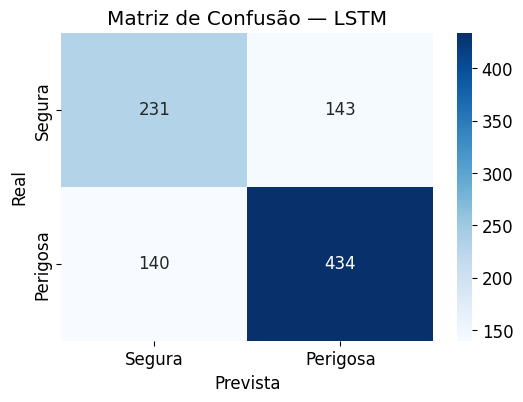

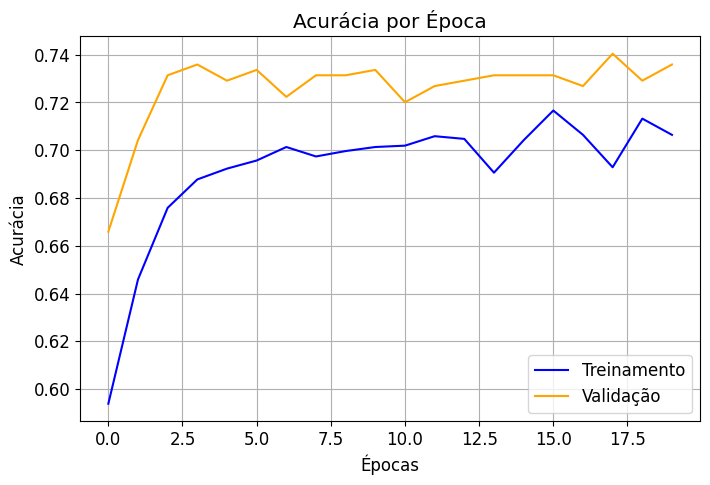

In [11]:
# LSTM
from sklearn.metrics import confusion_matrix

lstm_cfg = cfg['neural_networks']['lstm']
X_train_l, X_test_l, y_train_l, y_test_l, n_feat_l = preparar_dados_lstm(
    df_ml, janela_tempo=lstm_cfg['janela_tempo'], random_state=ml['random_state']
)
modelo_lstm = construir_lstm(lstm_cfg["janela_tempo"], n_feat_l)
modelo_lstm.summary()

history_lstm = modelo_lstm.fit(
    X_train_l, y_train_l,
    epochs=lstm_cfg['epochs'],
    batch_size=lstm_cfg['batch_size'],
    validation_split=lstm_cfg['validation_split'],
    verbose=1,
)

y_pred_lstm = np.argmax(modelo_lstm.predict(X_test_l), axis=1)
y_true_lstm = np.argmax(y_test_l, axis=1)

cm = confusion_matrix(y_true_lstm, y_pred_lstm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Segura', 'Perigosa'], yticklabels=['Segura', 'Perigosa'])
plt.title('Matriz de Confusão — LSTM')
plt.ylabel('Real'); plt.xlabel('Prevista')
plt.show()

plotar_curva_treinamento(history_lstm)